# Chapter 39: Camera Modeling and Calibration

This notebook is a compact executable companion to MIT Vision Book Chapter 39.
It keeps the chapter's original structure, displays every official MIT figure from the
MIT Vision Book directly in the notebook, and adds a small number of deterministic
CPU-friendly visualizations to make the geometry concrete.


In [1]:
import io
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import colors as mcolors
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

SEED = 39
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "index.ipynb").exists():
    candidate = NOTEBOOK_DIR / "notebooks" / "CV" / "2026" / "spring" / "final" / "chapter-39-camera-modeling"
    if candidate.exists():
        NOTEBOOK_DIR = candidate.resolve()
    else:
        matches = list(NOTEBOOK_DIR.rglob("chapter-39-camera-modeling/index.ipynb"))
        assert matches, f"Could not resolve the chapter directory from {Path.cwd()}"
        NOTEBOOK_DIR = matches[0].parent.resolve()

CHAPTER_DIR = NOTEBOOK_DIR

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#334155",
        "axes.labelcolor": "#0f172a",
        "axes.titlecolor": "#0f172a",
        "xtick.color": "#334155",
        "ytick.color": "#334155",
        "font.size": 11,
        "axes.grid": False,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#cbd5e1",
        "grid.color": "#cbd5e1",
        "grid.alpha": 0.45,
    }
)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "gray": "#475569",
    "light": "#94a3b8",
}


def savefig(fig, filename: str) -> None:
    del filename
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=180, bbox_inches="tight")
    buffer.seek(0)
    display(IPyImage(data=buffer.getvalue()))
    plt.close(fig)


def homogenize(points: torch.Tensor) -> torch.Tensor:
    ones = torch.ones((points.shape[0], 1), dtype=points.dtype)
    return torch.cat([points, ones], dim=1)


def rotation_x(angle_deg: float) -> torch.Tensor:
    t = math.radians(angle_deg)
    c, s = math.cos(t), math.sin(t)
    return torch.tensor([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]], dtype=torch.float64)


def rotation_y(angle_deg: float) -> torch.Tensor:
    t = math.radians(angle_deg)
    c, s = math.cos(t), math.sin(t)
    return torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], dtype=torch.float64)


def make_intrinsics(fx: float, fy: float, cx: float, cy: float) -> torch.Tensor:
    return torch.tensor([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], dtype=torch.float64)


def project_points(points_world: torch.Tensor, K: torch.Tensor, R: torch.Tensor, T: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    points_cam = (R @ (points_world - T).T).T
    pixels_h = (K @ points_cam.T).T
    pixels = pixels_h[:, :2] / pixels_h[:, 2:].clamp_min(1e-9)
    return pixels, points_cam


def build_dlt_matrix(points_world: torch.Tensor, pixels: torch.Tensor) -> torch.Tensor:
    rows = []
    for P, p in zip(points_world, pixels, strict=True):
        X, Y, Z = [float(v) for v in P]
        x, y = [float(v) for v in p]
        rows.append([-X, -Y, -Z, -1.0, 0.0, 0.0, 0.0, 0.0, x * X, x * Y, x * Z, x])
        rows.append([0.0, 0.0, 0.0, 0.0, -X, -Y, -Z, -1.0, y * X, y * Y, y * Z, y])
    return torch.tensor(rows, dtype=torch.float64)


def estimate_projection_matrix_dlt(points_world: torch.Tensor, pixels: torch.Tensor) -> torch.Tensor:
    A = build_dlt_matrix(points_world, pixels)
    _, _, vh = torch.linalg.svd(A)
    M = vh[-1].reshape(3, 4)
    return M / torch.linalg.norm(M)


def project_with_matrix(points_world: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    Xh = homogenize(points_world).T
    ph = (M @ Xh).T
    return ph[:, :2] / ph[:, 2:3].clamp_min(1e-9)


def light_grid(ax):
    ax.grid(True, linewidth=0.7, color="#cbd5e1", alpha=0.45)

from IPython.display import HTML, Image as IPyImage, display


def normalize_points_2d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid = points.mean(axis=0)
    mean_distance = np.linalg.norm(points - centroid, axis=1).mean()
    scale = math.sqrt(2.0) / max(mean_distance, 1e-9)
    T = np.array(
        [
            [scale, 0.0, -scale * centroid[0]],
            [0.0, scale, -scale * centroid[1]],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    normalized = (T @ points_h.T).T
    return normalized[:, :2], T


def normalize_points_3d(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid = points.mean(axis=0)
    mean_distance = np.linalg.norm(points - centroid, axis=1).mean()
    scale = math.sqrt(3.0) / max(mean_distance, 1e-9)
    U = np.array(
        [
            [scale, 0.0, 0.0, -scale * centroid[0]],
            [0.0, scale, 0.0, -scale * centroid[1]],
            [0.0, 0.0, scale, -scale * centroid[2]],
            [0.0, 0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    normalized = (U @ points_h.T).T
    return normalized[:, :3], U


def build_dlt_matrix_numpy(points_world: np.ndarray, pixels: np.ndarray) -> np.ndarray:
    rows = []
    for point_world, pixel in zip(points_world, pixels, strict=True):
        X, Y, Z = point_world
        u, v = pixel
        rows.append([0.0, 0.0, 0.0, 0.0, -X, -Y, -Z, -1.0, v * X, v * Y, v * Z, v])
        rows.append([X, Y, Z, 1.0, 0.0, 0.0, 0.0, 0.0, -u * X, -u * Y, -u * Z, -u])
    return np.asarray(rows, dtype=np.float64)


def estimate_projection_matrix_normalized_dlt(points_world: np.ndarray, pixels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    normalized_pixels, T = normalize_points_2d(pixels)
    normalized_world, U = normalize_points_3d(points_world)
    A = build_dlt_matrix_numpy(normalized_world, normalized_pixels)
    _, _, vh = np.linalg.svd(A)
    projection_normalized = vh[-1].reshape(3, 4)
    projection = np.linalg.inv(T) @ projection_normalized @ U
    projection = projection / np.linalg.norm(projection[2, :3])
    if projection[2, 3] > 0.0:
        projection = -projection
    return projection, A


def project_with_projection_matrix(points_world: np.ndarray, projection: np.ndarray) -> np.ndarray:
    points_h = np.concatenate([points_world, np.ones((points_world.shape[0], 1), dtype=np.float64)], axis=1)
    projected_h = (projection @ points_h.T).T
    return projected_h[:, :2] / projected_h[:, 2:3]


def rq_decomposition(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    q_matrix, r_matrix = np.linalg.qr(np.flipud(matrix).T)
    r_matrix = np.flipud(r_matrix.T)
    r_matrix = np.fliplr(r_matrix)
    q_matrix = q_matrix.T
    q_matrix = np.flipud(q_matrix)
    diagonal_signs = np.where(np.diag(r_matrix) >= 0.0, 1.0, -1.0)
    sign_matrix = np.diag(diagonal_signs)
    r_matrix = r_matrix @ sign_matrix
    q_matrix = sign_matrix @ q_matrix
    if np.linalg.det(q_matrix) < 0.0:
        sign_matrix = np.diag([1.0, 1.0, -1.0])
        r_matrix = r_matrix @ sign_matrix
        q_matrix = sign_matrix @ q_matrix
    return r_matrix, q_matrix


def decompose_projection_matrix(projection: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    camera_matrix = projection[:, :3]
    intrinsics, rotation = rq_decomposition(camera_matrix)
    sign_matrix = np.diag(
        [
            -1.0 if intrinsics[0, 0] < 0.0 else 1.0,
            -1.0 if intrinsics[1, 1] < 0.0 else 1.0,
            1.0,
        ]
    )
    intrinsics = intrinsics @ sign_matrix
    rotation = sign_matrix @ rotation
    intrinsics = intrinsics / intrinsics[2, 2]
    translation = np.linalg.solve(intrinsics, projection[:, 3])
    camera_center = -np.linalg.inv(camera_matrix) @ projection[:, 3]
    return intrinsics, rotation, translation, camera_center


def render_html_table(rows: list[dict[str, object]], headers: list[str]) -> None:
    def fmt(value: object) -> str:
        if isinstance(value, float):
            return f"{value:.2f}"
        return str(value)

    header_html = ''.join(
        f'<th style="border:1px solid #cbd5e1;padding:6px 8px;background:#e2e8f0;text-align:left;">{header}</th>'
        for header in headers
    )
    body_html = []
    for row in rows:
        cells = ''.join(
            f'<td style="border:1px solid #cbd5e1;padding:6px 8px;vertical-align:top;">{fmt(row[header])}</td>'
            for header in headers
        )
        body_html.append(f'<tr>{cells}</tr>')
    html = (
        '<table style="border-collapse:collapse;font-size:0.92rem;min-width:720px;">'
        f'<thead><tr>{header_html}</tr></thead>'
        f'<tbody>{"".join(body_html)}</tbody></table>'
    )
    display(HTML(html))


def set_axes_equal(ax) -> None:
    x_limits = np.array(ax.get_xlim3d(), dtype=np.float64)
    y_limits = np.array(ax.get_ylim3d(), dtype=np.float64)
    z_limits = np.array(ax.get_zlim3d(), dtype=np.float64)
    spans = np.array([x_limits[1] - x_limits[0], y_limits[1] - y_limits[0], z_limits[1] - z_limits[0]])
    centers = np.array([x_limits.mean(), y_limits.mean(), z_limits.mean()])
    radius = 0.5 * spans.max()
    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])


## 39.1 Introduction

Chapter 39 shifts from the simple pinhole stories of earlier chapters to a more useful
camera model: one that can describe where the camera sits in the world, how it is
oriented, and how 3D points become pixels.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/world_and_camera_coordinates.png" alt="MIT Vision Book Figure 39.1" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.1, Figure 39.1. This original textbook figure contrasts a camera-centered frame with a world-centered frame. It matters here because the whole chapter is about moving between those frames cleanly.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/the_picture.png" alt="MIT Vision Book Figure 39.2" style="width: 38%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.1, Figure 39.2. This original textbook figure shows the image whose geometry the chapter later models. It matters because calibration always connects a real picture back to a 3D scene.</em></p>
</div>

The chapter's core idea is that calibration is about estimating the transformation from
world coordinates to image coordinates. Intrinsic parameters describe the camera itself.
Extrinsic parameters describe the camera's position and pose relative to the scene.


## 39.2 3D Camera Projections in Homogeneous Coordinates

Perspective projection contains a division by depth, which makes the equations awkward in
ordinary Euclidean coordinates. Homogeneous coordinates let us express the same mapping as
a matrix multiplication followed by a normalization step.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/camera_centric.png" alt="MIT Vision Book Figure 39.3" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.2, Figure 39.3. This original textbook figure shows how a 3D point projects through a pinhole onto the image plane. It matters because homogeneous coordinates re-express this geometry in matrix form.</em></p>
</div>

The point to keep in mind is that a 3D location `P = [X, Y, Z]^T` projects to image
coordinates roughly proportional to `X/Z` and `Y/Z`. Nearby points look larger because
dividing by a smaller depth amplifies the image coordinates.

### 39.2.1 Parallel Projection

Parallel projection removes that depth-dependent division. It is a simpler model that is
sometimes useful for distant scenes or for deriving intuition, but it does not capture
the foreshortening that real pinhole cameras produce.


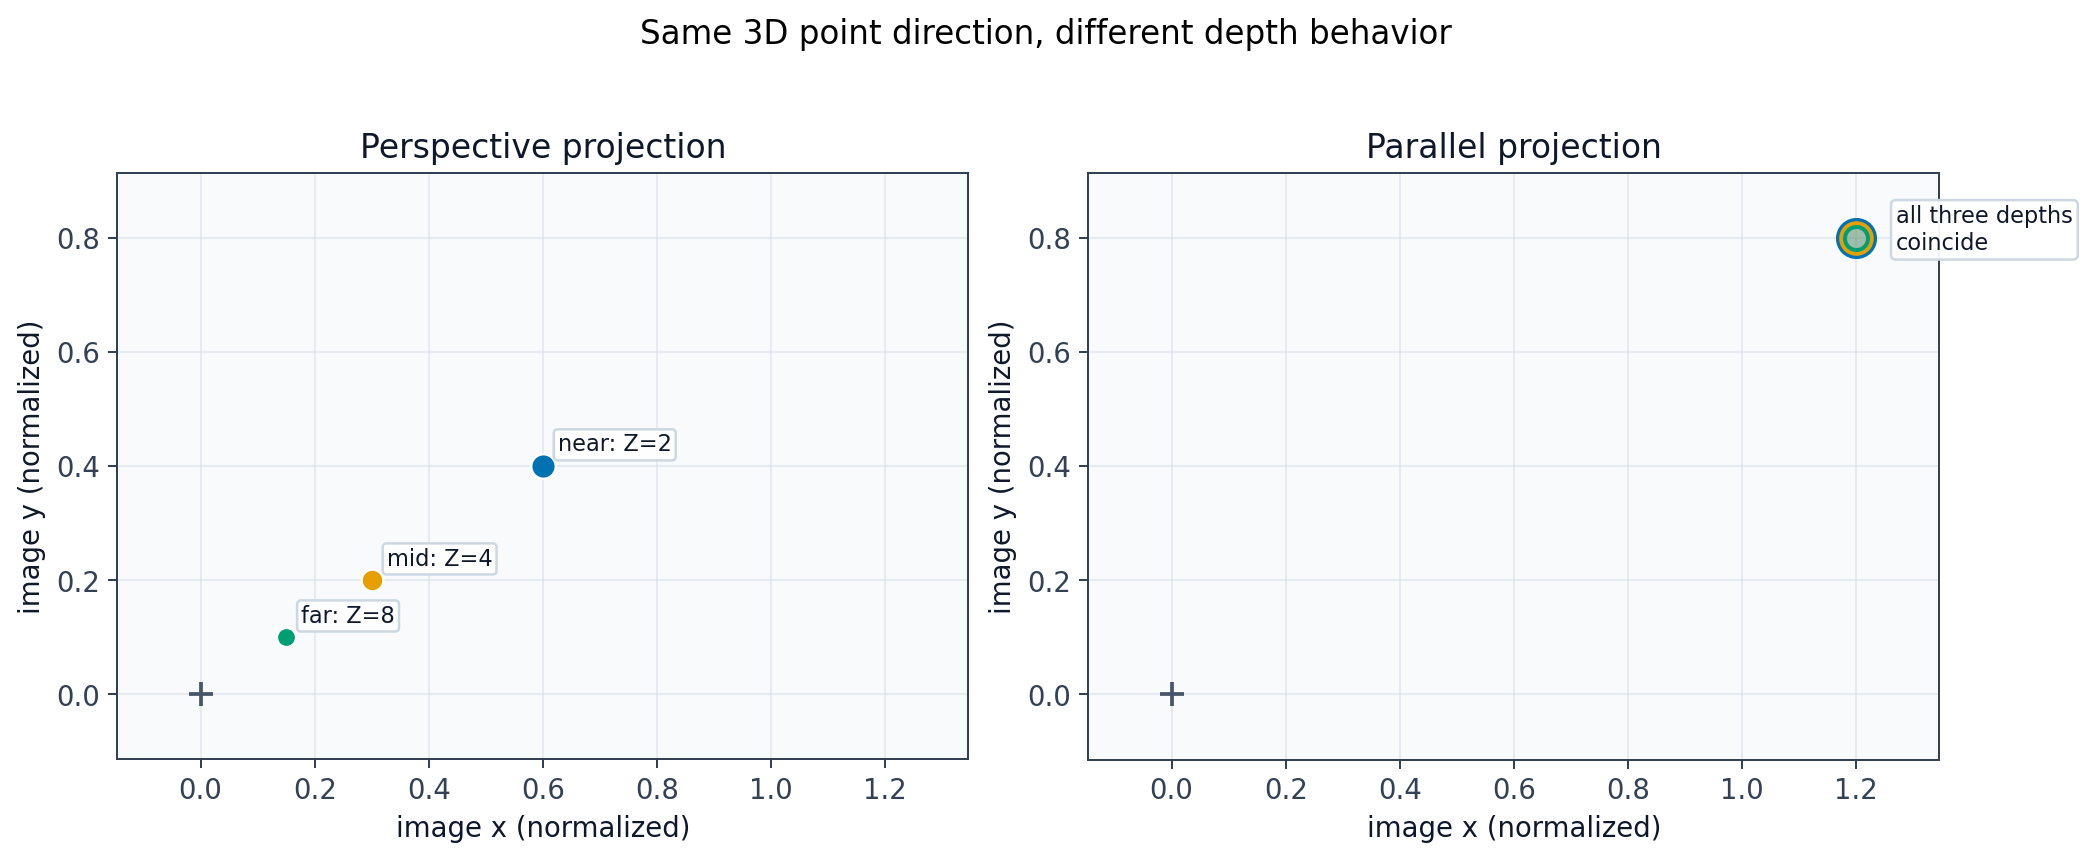

In [2]:
z_values = torch.tensor([2.0, 4.0, 8.0], dtype=torch.float64)
xy = torch.tensor([1.2, 0.8], dtype=torch.float64)
principal_point = torch.tensor([0.0, 0.0], dtype=torch.float64)
perspective_points = torch.stack([xy / z for z in z_values])
parallel_point = xy.clone()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)

labels = ["near", "mid", "far"]
colors = [COLORS["blue"], COLORS["orange"], COLORS["green"]]
marker_sizes = [95, 75, 58]

persp_all = torch.vstack([perspective_points, principal_point.unsqueeze(0)])
parallel_all = torch.vstack([parallel_point.unsqueeze(0), principal_point.unsqueeze(0)])
all_points = torch.vstack([persp_all, parallel_all])
pad_x = 0.08 * float(all_points[:, 0].max() - all_points[:, 0].min()) + 0.05
pad_y = 0.08 * float(all_points[:, 1].max() - all_points[:, 1].min()) + 0.05
xlim = (float(all_points[:, 0].min()) - pad_x, float(all_points[:, 0].max()) + pad_x)
ylim = (float(all_points[:, 1].min()) - pad_y, float(all_points[:, 1].max()) + pad_y)

ax = axes[0]
for point, depth, label, color, size in zip(perspective_points, z_values, labels, colors, marker_sizes, strict=True):
    ax.scatter(float(point[0]), float(point[1]), s=size, color=color, edgecolor="white", linewidth=0.9, zorder=3)
    ax.annotate(
        f"{label}: Z={depth:.0f}",
        xy=(float(point[0]), float(point[1])),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="#cbd5e1", alpha=0.95),
    )
ax.scatter(float(principal_point[0]), float(principal_point[1]), marker="+", s=90, color=COLORS["gray"], linewidth=1.5, zorder=4)
ax.set_title("Perspective projection")
ax.set_xlabel("image x (normalized)")
ax.set_ylabel("image y (normalized)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
light_grid(ax)

ax = axes[1]
for depth, color, size, alpha in zip(z_values, colors, [220, 150, 85], [0.32, 0.22, 0.12], strict=True):
    ax.scatter(
        float(parallel_point[0]),
        float(parallel_point[1]),
        s=size,
        facecolor=mcolors.to_rgba(color, alpha),
        edgecolor=color,
        linewidth=1.6,
        zorder=3,
        label=f"Z={depth:.0f}",
    )
ax.scatter(float(principal_point[0]), float(principal_point[1]), marker="+", s=90, color=COLORS["gray"], linewidth=1.5, zorder=4)
ax.text(
    float(parallel_point[0]) + 0.07,
    float(parallel_point[1]) - 0.02,
    "all three depths\ncoincide",
    fontsize=9,
    color="#0f172a",
    bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="#cbd5e1", alpha=0.95),
)
ax.set_title("Parallel projection")
ax.set_xlabel("image x (normalized)")
ax.set_ylabel("image y (normalized)")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
light_grid(ax)

fig.suptitle("Same 3D point direction, different depth behavior", fontsize=13)
savefig(fig, "01-projection-models.png")


**Supplemental visualization for MIT Vision Book Section 39.2.**

We projected the same lateral 3D point at three depths using both perspective and parallel projection. The perspective panel shrinks image coordinates with increasing depth, while the parallel panel keeps them fixed. That is the key geometric difference between Sections 39.2 and 39.2.1.


## 39.3 Camera-Intrinsic Parameters

Intrinsic parameters describe how the camera turns rays into pixels. In practice, this
includes focal scaling, the principal point, and sometimes unequal pixel scales, skew,
or lens distortion.

### 39.3.1 From Meters to Pixels

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/pinhole_and_sensor.png" alt="MIT Vision Book Figure 39.4" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.1, Figure 39.4. This original textbook figure shows how focal length, sensor width, and pixel sampling connect physical geometry to image coordinates. It matters because intrinsic calibration lives in that conversion.</em></p>
</div>

The intrinsic matrix tells us how to convert camera-plane coordinates into pixel
coordinates. The chapter uses `a` and `b` for horizontal and vertical focal scaling, and
`(c_x, c_y)` for the principal point.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/conventions_coordinates.png" alt="MIT Vision Book Figure 39.5" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.1, Figure 39.5. This original textbook figure compares common image-coordinate conventions. It matters because sign choices and origin placement change how we write the intrinsic matrix.</em></p>
</div>

In code, it is worth being explicit about conventions: image origins, axis directions,
and sign choices all affect the exact matrix form even when the geometry is the same.

### 39.3.2 From Pixels to Rays

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/light_ray.png" alt="MIT Vision Book Figure 39.6" style="width: 76%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.2, Figure 39.6. This original textbook figure shows that a single pixel defines a whole 3D ray, not a unique 3D point. It matters because depth is what turns that ray back into a specific scene location.</em></p>
</div>

Backprojection reverses the forward camera map only up to a ray. If a pixel is known and
the depth is unknown, there are infinitely many 3D points consistent with that pixel.

### 39.3.3 A Simple, although Unreliable, Calibration Method

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
<img src="https://visionbook.mit.edu/figures/imaging_geometry/simple_calibration_1.jpg" alt="MIT Vision Book Figure 39.7" style="width: 60%; max-width: 100%; height: auto;" />
<img src="https://visionbook.mit.edu/figures/imaging_geometry/simple_calibration_2.jpg" alt="MIT Vision Book Figure 39.7" style="width: 32%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.3.3, Figure 39.7. This original textbook figure groups the physical setup and the captured chessboard image. It matters because the chapter first introduces calibration as a measurement problem before presenting more general estimation methods.</em></p>
</div>

This sanity-check method uses a known target, a measured distance, and the apparent size
of the target in the image to estimate focal scaling. It is useful for intuition, but it
ignores many practical effects such as distortion and imperfect alignment.

### 39.3.4 Other Camera Parameters

Real cameras may also need skew terms, separate horizontal and vertical pixel scales, and
especially distortion correction. In practice, radial distortion is often the first extra
effect that visibly breaks the simplest pinhole model.


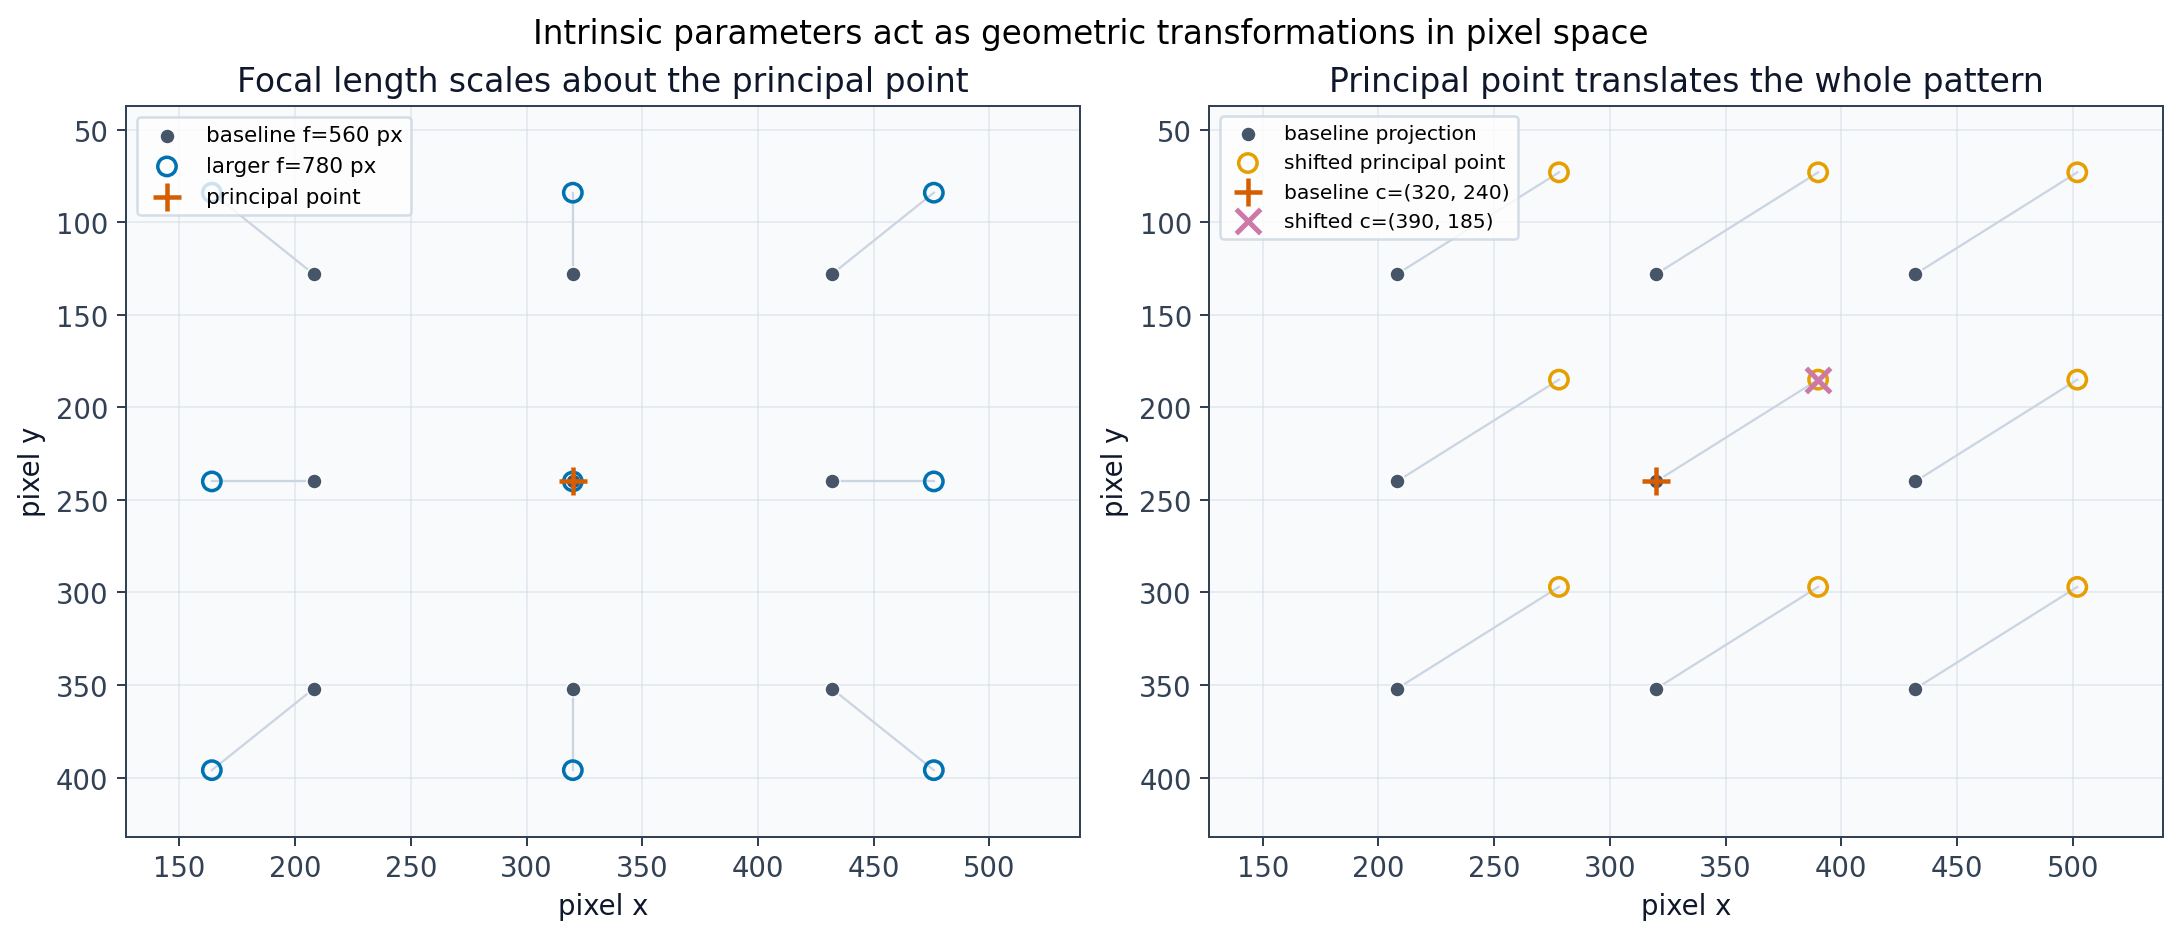

In [3]:
pattern_xy = torch.tensor(
    [
        [-0.9, -0.9], [0.0, -0.9], [0.9, -0.9],
        [-0.9,  0.0], [0.0,  0.0], [0.9,  0.0],
        [-0.9,  0.9], [0.0,  0.9], [0.9,  0.9],
    ],
    dtype=torch.float64,
)
pattern_depth = torch.full((pattern_xy.shape[0], 1), 4.5, dtype=torch.float64)
pattern_3d = torch.cat([pattern_xy, pattern_depth], dim=1)
K_base = make_intrinsics(560.0, 560.0, 320.0, 240.0)
K_focal = make_intrinsics(780.0, 780.0, 320.0, 240.0)
K_shift = make_intrinsics(560.0, 560.0, 390.0, 185.0)
R_eye = torch.eye(3, dtype=torch.float64)
T_zero = torch.zeros(3, dtype=torch.float64)

baseline_pixels, _ = project_points(pattern_3d, K_base, R_eye, T_zero)
focal_pixels, _ = project_points(pattern_3d, K_focal, R_eye, T_zero)
shift_pixels, _ = project_points(pattern_3d, K_shift, R_eye, T_zero)
principal_base = torch.tensor([320.0, 240.0], dtype=torch.float64)
principal_shift = torch.tensor([390.0, 185.0], dtype=torch.float64)

all_points = torch.vstack([baseline_pixels, focal_pixels, shift_pixels, principal_base.unsqueeze(0), principal_shift.unsqueeze(0)])
pad_x = 0.08 * float(all_points[:, 0].max() - all_points[:, 0].min()) + 10.0
pad_y = 0.08 * float(all_points[:, 1].max() - all_points[:, 1].min()) + 10.0
xlim = (float(all_points[:, 0].min()) - pad_x, float(all_points[:, 0].max()) + pad_x)
y_top = float(all_points[:, 1].min()) - pad_y
y_bottom = float(all_points[:, 1].max()) + pad_y

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.1), constrained_layout=True)

ax = axes[0]
for base_pt, changed_pt in zip(baseline_pixels, focal_pixels, strict=True):
    ax.plot([float(base_pt[0]), float(changed_pt[0])], [float(base_pt[1]), float(changed_pt[1])], color="#cbd5e1", lw=0.9, zorder=1)
ax.scatter(baseline_pixels[:, 0], baseline_pixels[:, 1], s=36, color=COLORS["gray"], edgecolor="white", linewidth=0.6, label="baseline f=560 px", zorder=3)
ax.scatter(focal_pixels[:, 0], focal_pixels[:, 1], s=54, facecolor="none", edgecolor=COLORS["blue"], linewidth=1.4, label="larger f=780 px", zorder=4)
ax.scatter([float(principal_base[0])], [float(principal_base[1])], marker="+", s=120, color=COLORS["vermillion"], linewidth=1.8, label="principal point", zorder=5)
ax.set_title("Focal length scales about the principal point")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(*xlim)
ax.set_ylim(y_bottom, y_top)
light_grid(ax)
ax.legend(loc="upper left", fontsize=8.6)

ax = axes[1]
for base_pt, changed_pt in zip(baseline_pixels, shift_pixels, strict=True):
    ax.plot([float(base_pt[0]), float(changed_pt[0])], [float(base_pt[1]), float(changed_pt[1])], color="#cbd5e1", lw=0.9, zorder=1)
ax.scatter(baseline_pixels[:, 0], baseline_pixels[:, 1], s=36, color=COLORS["gray"], edgecolor="white", linewidth=0.6, label="baseline projection", zorder=3)
ax.scatter(shift_pixels[:, 0], shift_pixels[:, 1], s=54, facecolor="none", edgecolor=COLORS["orange"], linewidth=1.4, label="shifted principal point", zorder=4)
ax.scatter([float(principal_base[0])], [float(principal_base[1])], marker="+", s=120, color=COLORS["vermillion"], linewidth=1.8, label="baseline c=(320, 240)", zorder=5)
ax.scatter([float(principal_shift[0])], [float(principal_shift[1])], marker="x", s=95, color=COLORS["purple"], linewidth=2.0, label="shifted c=(390, 185)", zorder=5)
ax.set_title("Principal point translates the whole pattern")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_xlim(*xlim)
ax.set_ylim(y_bottom, y_top)
light_grid(ax)
ax.legend(loc="upper left", fontsize=8.1)

fig.suptitle("Intrinsic parameters act as geometric transformations in pixel space", fontsize=13)
savefig(fig, "02-intrinsics-effects.png")


**Computational reconstruction related to MIT Vision Book Section 39.3, Figure 39.4.**

We projected the same nine 3D points while changing either focal scaling or the principal point. Larger focal length magnifies the image, while changing `(c_x, c_y)` translates all projected points together. Those are two of the central effects encoded by the intrinsic matrix.


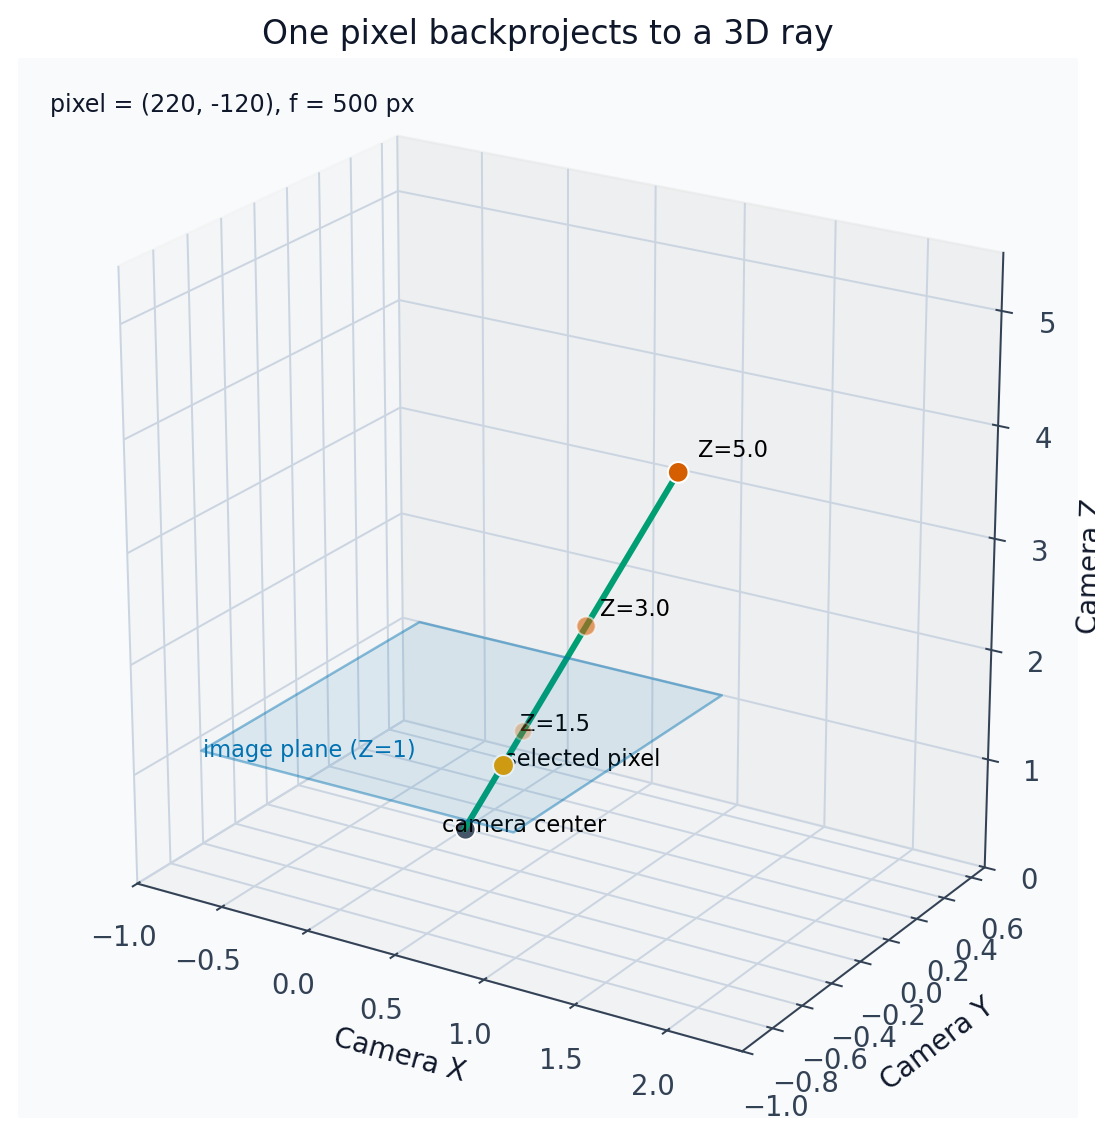

In [4]:
pixel = torch.tensor([220.0, -120.0], dtype=torch.float64)
focal = 500.0
depths = torch.tensor([1.5, 3.0, 5.0], dtype=torch.float64)
plane_depth = 1.0
pixel_on_plane = torch.tensor([pixel[0] / focal, pixel[1] / focal, plane_depth], dtype=torch.float64)
ray_dir = pixel_on_plane.clone()
ray_points = depths.unsqueeze(1) * ray_dir.unsqueeze(0)

plane_w, plane_h = 0.9, 0.7
plane_vertices = [
    [-plane_w, -plane_h, plane_depth],
    [ plane_w, -plane_h, plane_depth],
    [ plane_w,  plane_h, plane_depth],
    [-plane_w,  plane_h, plane_depth],
]

fig = plt.figure(figsize=(8.2, 6.2), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
a = Poly3DCollection([plane_vertices], facecolors=mcolors.to_rgba(COLORS["blue"], 0.10), edgecolors=mcolors.to_rgba(COLORS["blue"], 0.45), linewidths=1.0)
ax.add_collection3d(a)
ax.plot([0.0, float(ray_points[-1, 0])], [0.0, float(ray_points[-1, 1])], [0.0, float(ray_points[-1, 2])], color=COLORS["green"], lw=2.4, zorder=3)
ax.scatter([0.0], [0.0], [0.0], color=COLORS["gray"], s=64, edgecolor="white", linewidth=0.7, zorder=5)
ax.scatter([float(pixel_on_plane[0])], [float(pixel_on_plane[1])], [plane_depth], color=COLORS["orange"], s=70, edgecolor="white", linewidth=0.8, zorder=6)
ax.scatter(ray_points[:, 0], ray_points[:, 1], ray_points[:, 2], color=COLORS["vermillion"], s=[48, 58, 68], edgecolor="white", linewidth=0.8, zorder=7)

label_offsets = [(0.05, -0.08, 0.10), (0.06, 0.02, 0.10), (0.05, 0.06, 0.10)]
for point, depth, (dx, dy, dz) in zip(ray_points, depths, label_offsets, strict=True):
    ax.text(float(point[0] + dx), float(point[1] + dy), float(point[2] + dz), f"Z={depth:.1f}", fontsize=9)

ax.text2D(0.03, 0.95, "pixel = (220, -120), f = 500 px", transform=ax.transAxes, fontsize=9.5, color="#0f172a")
ax.text(float(pixel_on_plane[0] + 0.04), float(pixel_on_plane[1] - 0.03), float(pixel_on_plane[2] + 0.04), "selected pixel", fontsize=9)
ax.text(-0.08, -0.06, 0.0, "camera center", fontsize=9)
ax.text(-0.83, -0.76, plane_depth + 0.03, "image plane (Z=1)", fontsize=9, color=COLORS["blue"])
ax.set_title("One pixel backprojects to a 3D ray")
ax.set_xlabel("Camera X")
ax.set_ylabel("Camera Y")
ax.set_zlabel("Camera Z")
ax.set_xlim(-1.0, 2.4)
ax.set_ylim(-1.0, 0.7)
ax.set_zlim(0.0, 5.5)
ax.set_box_aspect((1.45, 1.0, 1.35))
ax.view_init(elev=22, azim=-58)
savefig(fig, "03-pixel-to-ray-backprojection.png")


**Computational reconstruction related to MIT Vision Book Section 39.3.2, Figure 39.6.**

We chose one pixel direction and sampled three depths along its backprojected ray. The computed points all correspond to the same image location, which is exactly why a pixel alone is insufficient to recover a unique 3D point.


## 39.4 Camera-Extrinsic Parameters

Extrinsic parameters answer a different question from intrinsics: where is the camera in
the world, and how is it rotated relative to the world frame?

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/world_and_camera_coordinates_2.png" alt="MIT Vision Book Figure 39.8" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.4, Figure 39.8. This original textbook figure shows the extrinsic relationship between the world frame and the camera frame. It matters because `R` and `T` explain where the camera is and how it is oriented.</em></p>
</div>

The chapter writes this mapping as a rotation followed by a translation in homogeneous
coordinates. Once points are expressed in the camera frame, the intrinsic matrix can
project them into the image.

## 39.5 Full Camera Model

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/summary_camera_model.png" alt="MIT Vision Book Figure 39.9" style="width: 82%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.5, Figure 39.9. This original textbook figure summarizes the full pipeline from world coordinates to camera coordinates to pixels. It matters because the projection matrix combines all of those steps.</em></p>
</div>

The full projection matrix composes intrinsics with extrinsics. In compact notation, the
camera matrix is often written as `M = K [R | -RT]`.

## 39.6 A Few Concrete Examples

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/camera_calibration_scenarios.png" alt="MIT Vision Book Figure 39.10" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.10. This original textbook figure collects the concrete camera-pose cases discussed in the chapter. It matters because the same matrix model can represent all of them.</em></p>
</div>

The chapter then walks through level cameras, tilted cameras, and more structured ground
scenes to show how pose affects the final image equations.

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/horizon_heads.jpg" alt="MIT Vision Book Figure 39.11" style="width: 62%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.11. This original textbook figure shows a practical horizon cue in a level camera. It matters because camera orientation leaves visible traces in ordinary photographs.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/eyes_location.png" alt="MIT Vision Book Figure 39.12" style="width: 92%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.12. This original textbook figure sketches why equal-height points can line up in the image despite being at different depths. It matters because the horizon is a geometric consequence of camera pose.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
<img src="https://visionbook.mit.edu/figures/imaging_geometry/low_horizon_vp.jpg" alt="MIT Vision Book Figure 39.13" style="width: 48%; max-width: 100%; height: auto;" />
<img src="https://visionbook.mit.edu/figures/imaging_geometry/high_horizon_vp.jpg" alt="MIT Vision Book Figure 39.13" style="width: 48%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.6, Figure 39.13. This original textbook figure groups two photos taken with different camera tilt angles. It matters because changing the camera pitch shifts the horizon line in a predictable way.</em></p>
</div>

A helpful way to read these examples is to ask which quantities stay fixed when the
camera tilts or translates. Horizon-line motion is especially useful because it gives a
visible signature of camera pitch.


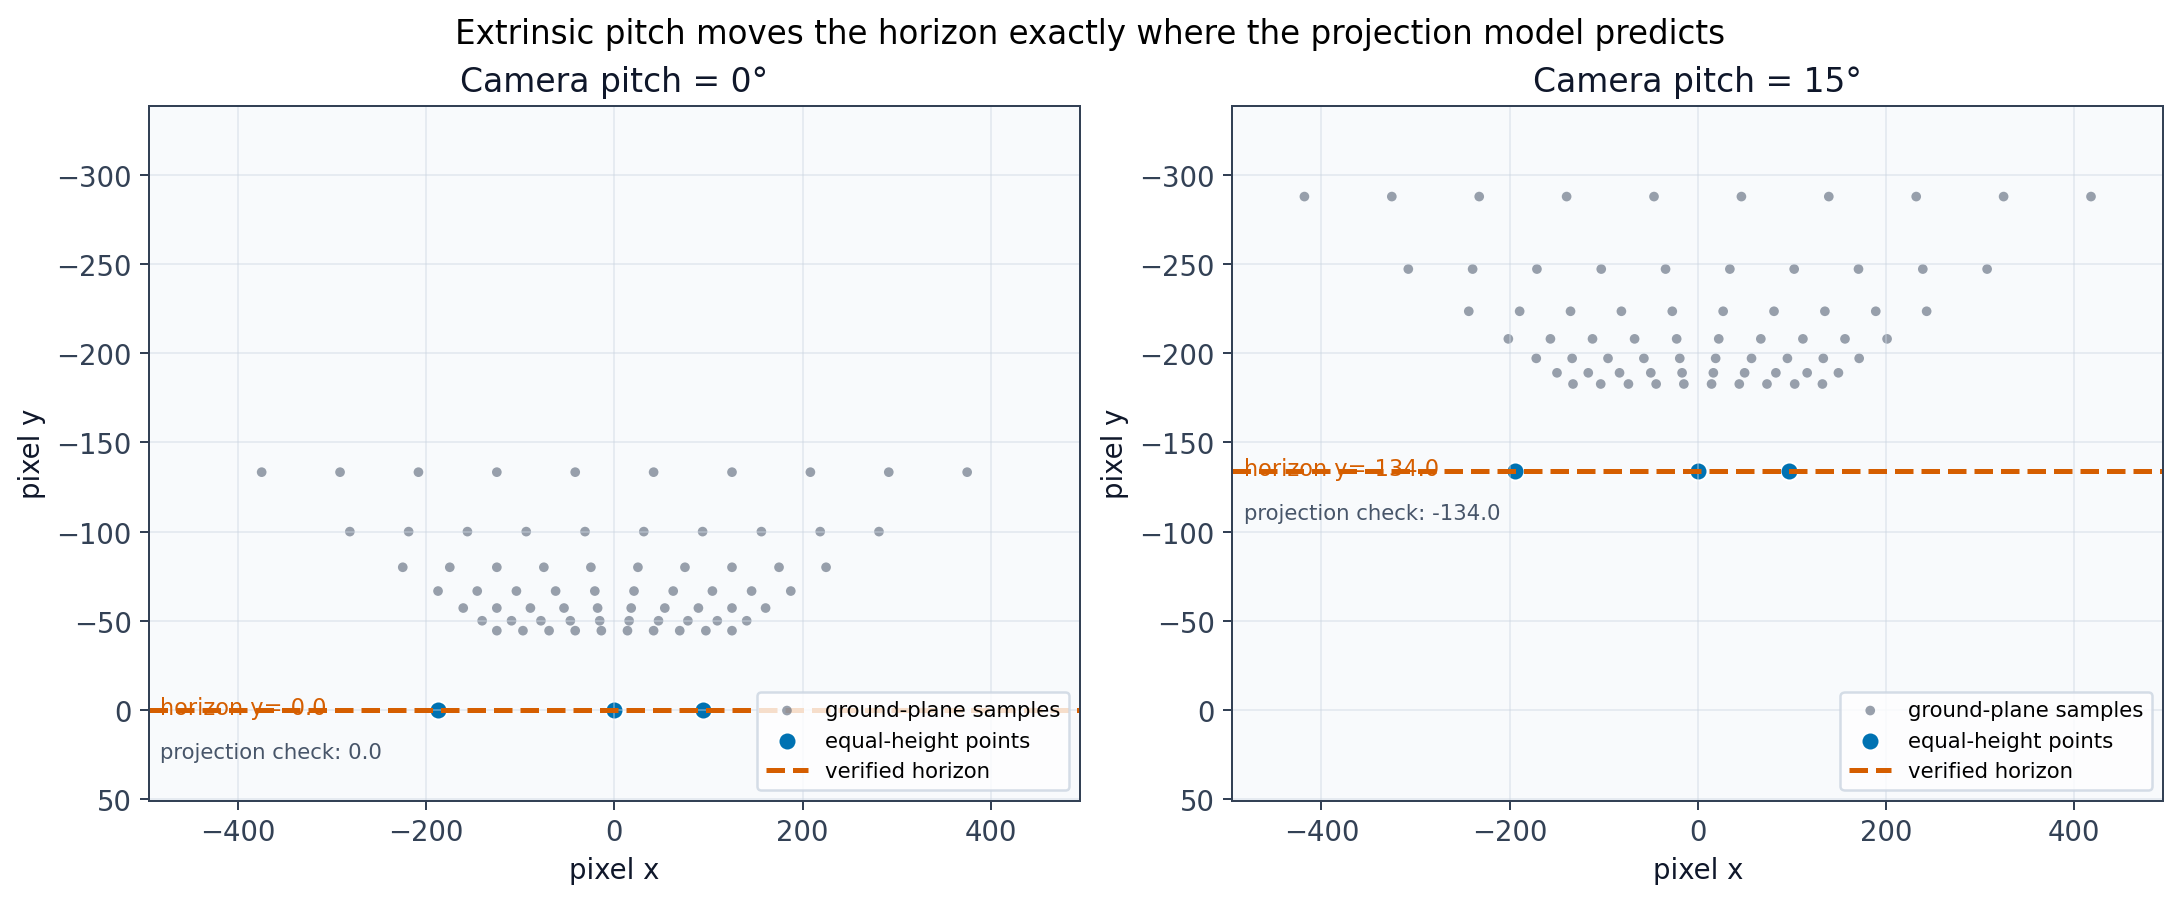

In [5]:
K = make_intrinsics(500.0, 500.0, 0.0, 0.0)
T = torch.tensor([0.0, 1.6, 0.0], dtype=torch.float64)
pitches = [0.0, 15.0]

ground_x = torch.linspace(-4.5, 4.5, 10, dtype=torch.float64)
ground_z = torch.linspace(6.0, 18.0, 7, dtype=torch.float64)
ground_points = torch.tensor([[float(x), 0.0, float(z)] for z in ground_z for x in ground_x], dtype=torch.float64)
horizon_points = torch.tensor([[float(x), float(T[1]), 1500.0] for x in torch.linspace(-6.0, 6.0, 13, dtype=torch.float64)], dtype=torch.float64)
reference_people = torch.tensor([[-3.0, float(T[1]), 8.0], [0.0, float(T[1]), 12.0], [3.0, float(T[1]), 16.0]], dtype=torch.float64)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.9), constrained_layout=True)
panel_data = []
for pitch in pitches:
    R = rotation_x(pitch)
    ground_pixels, _ = project_points(ground_points, K, R, T)
    equal_height_pixels, _ = project_points(reference_people, K, R, T)
    far_pixels, _ = project_points(horizon_points, K, R, T)
    horizon_y = float(far_pixels[:, 1].mean())
    verified_horizon_y = -float(K[1, 1]) * math.tan(math.radians(pitch))
    panel_data.append((pitch, ground_pixels, equal_height_pixels, horizon_y, verified_horizon_y))

all_x = torch.cat([item[1][:, 0] for item in panel_data] + [item[2][:, 0] for item in panel_data])
all_y = torch.cat(
    [item[1][:, 1] for item in panel_data]
    + [item[2][:, 1] for item in panel_data]
    + [torch.tensor([item[3], item[4]], dtype=torch.float64) for item in panel_data]
)
pad_x = 0.07 * float(all_x.max() - all_x.min()) + 18.0
pad_y = 0.10 * float(all_y.max() - all_y.min()) + 22.0
xlim = (float(all_x.min()) - pad_x, float(all_x.max()) + pad_x)
ylim = (float(all_y.min()) - pad_y, float(all_y.max()) + pad_y)

for ax, (pitch, ground_pixels, equal_height_pixels, horizon_y, verified_horizon_y) in zip(axes, panel_data, strict=True):
    ax.scatter(ground_pixels[:, 0], ground_pixels[:, 1], s=15, color=mcolors.to_rgba(COLORS["gray"], 0.55), edgecolor="none", label="ground-plane samples")
    ax.scatter(equal_height_pixels[:, 0], equal_height_pixels[:, 1], s=52, color=COLORS["blue"], edgecolor="white", linewidth=0.8, label="equal-height points")
    # With P_C = R(P_W - T), the implemented positive downward pitch places the horizon at y = -f tan(theta).
    ax.axhline(verified_horizon_y, color=COLORS["vermillion"], linestyle="--", lw=2.0, label="verified horizon")
    ax.text(xlim[0] + 12.0, verified_horizon_y - 8.0, f"horizon y={verified_horizon_y:.1f}", color=COLORS["vermillion"], fontsize=9, va="top")
    ax.text(xlim[0] + 12.0, verified_horizon_y + 18.0, f"projection check: {horizon_y:.1f}", color=COLORS["gray"], fontsize=8.5, va="top")
    ax.set_title(f"Camera pitch = {pitch:.0f}°")
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.invert_yaxis()
    light_grid(ax)
    ax.legend(loc="lower right", fontsize=8.5)

fig.suptitle("Extrinsic pitch moves the horizon exactly where the projection model predicts", fontsize=13)
savefig(fig, "04-extrinsics-and-horizon.png")


**Supplemental visualization for MIT Vision Book Section 39.6.**

We projected a small set of equal-height scene points with a level camera and with a 15 degree downward pitch. The dashed line marks the numerically verified horizon height `y_h = -f tan(theta)` under the notebook convention `P_C = R(P_W - T)`, and the displayed image coordinates use the standard image convention where `y` increases downward.


## 39.7 Camera Calibration

Calibration estimates the mapping from known 3D scene points to observed 2D image
points. The chapter first introduces a linear estimate of the projection matrix and then
discusses how to recover more interpretable intrinsic and extrinsic parameters.

### 39.7.1 Direct Linear Transform

DLT solves for a projection matrix by stacking linear equations from several 3D-to-2D
correspondences. The result is determined only up to an overall scale, which is fine for
projective geometry.

### 39.7.2 Recovering Intrinsic and Extrinsic Camera Parameters

Once a projection matrix has been estimated, we still need to factor it into camera
intrinsics and pose. Conceptually, this means separating the left `3x3` calibration part
from the world-to-camera pose terms.

### 39.7.3 Multiplane Calibration Method

Multiplane calibration uses several views of a known planar target to stabilize the
parameter estimates. This is closer to what practical camera-calibration toolkits do.

### 39.7.4 Nonlinear Optimization by Minimizing Reprojection Error

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/reprojection_error.png" alt="MIT Vision Book Figure 39.14" style="width: 62%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.4, Figure 39.14. This original textbook figure shows reprojection error directly on the image plane. It matters because nonlinear refinement usually optimizes camera parameters by minimizing this quantity.</em></p>
</div>

Linear estimates are often only the starting point. A better model is usually obtained by
refining parameters to minimize the distance between observed image points and predicted
image points.

### 39.7.5 A Toy Example

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/office_with_measures_2.jpg" alt="MIT Vision Book Figure 39.15" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.15. This original textbook figure shows the real office scene used in the toy calibration example. It matters because the later 3D annotations are grounded in these measurements.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/correspondences_img.png" alt="MIT Vision Book Figure 39.16" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.16. This original textbook figure pairs image observations with measured 3D coordinates. It matters because calibration needs matched 3D scene points and 2D image points.</em></p>
</div>

<div style="text-align: center; margin: 1rem 0;">
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: center; align-items: flex-start;">
    <img src="https://visionbook.mit.edu/figures/imaging_geometry/result_toymodel_3dscene_and_estimated_camera_b.png" alt="MIT Vision Book Figure 39.17" style="width: 100%; max-width: 100%; height: auto;" />
  </div>
  <p><em>MIT Vision Book — Section 39.7.5, Figure 39.17. This original textbook figure visualizes the inferred camera location from several viewpoints. It matters because a good calibration should produce a physically plausible camera pose.</em></p>
</div>

The office example shows the whole calibration story end to end: measure some 3D
positions, annotate the corresponding image points, estimate the camera, and then inspect
whether the result is plausible.


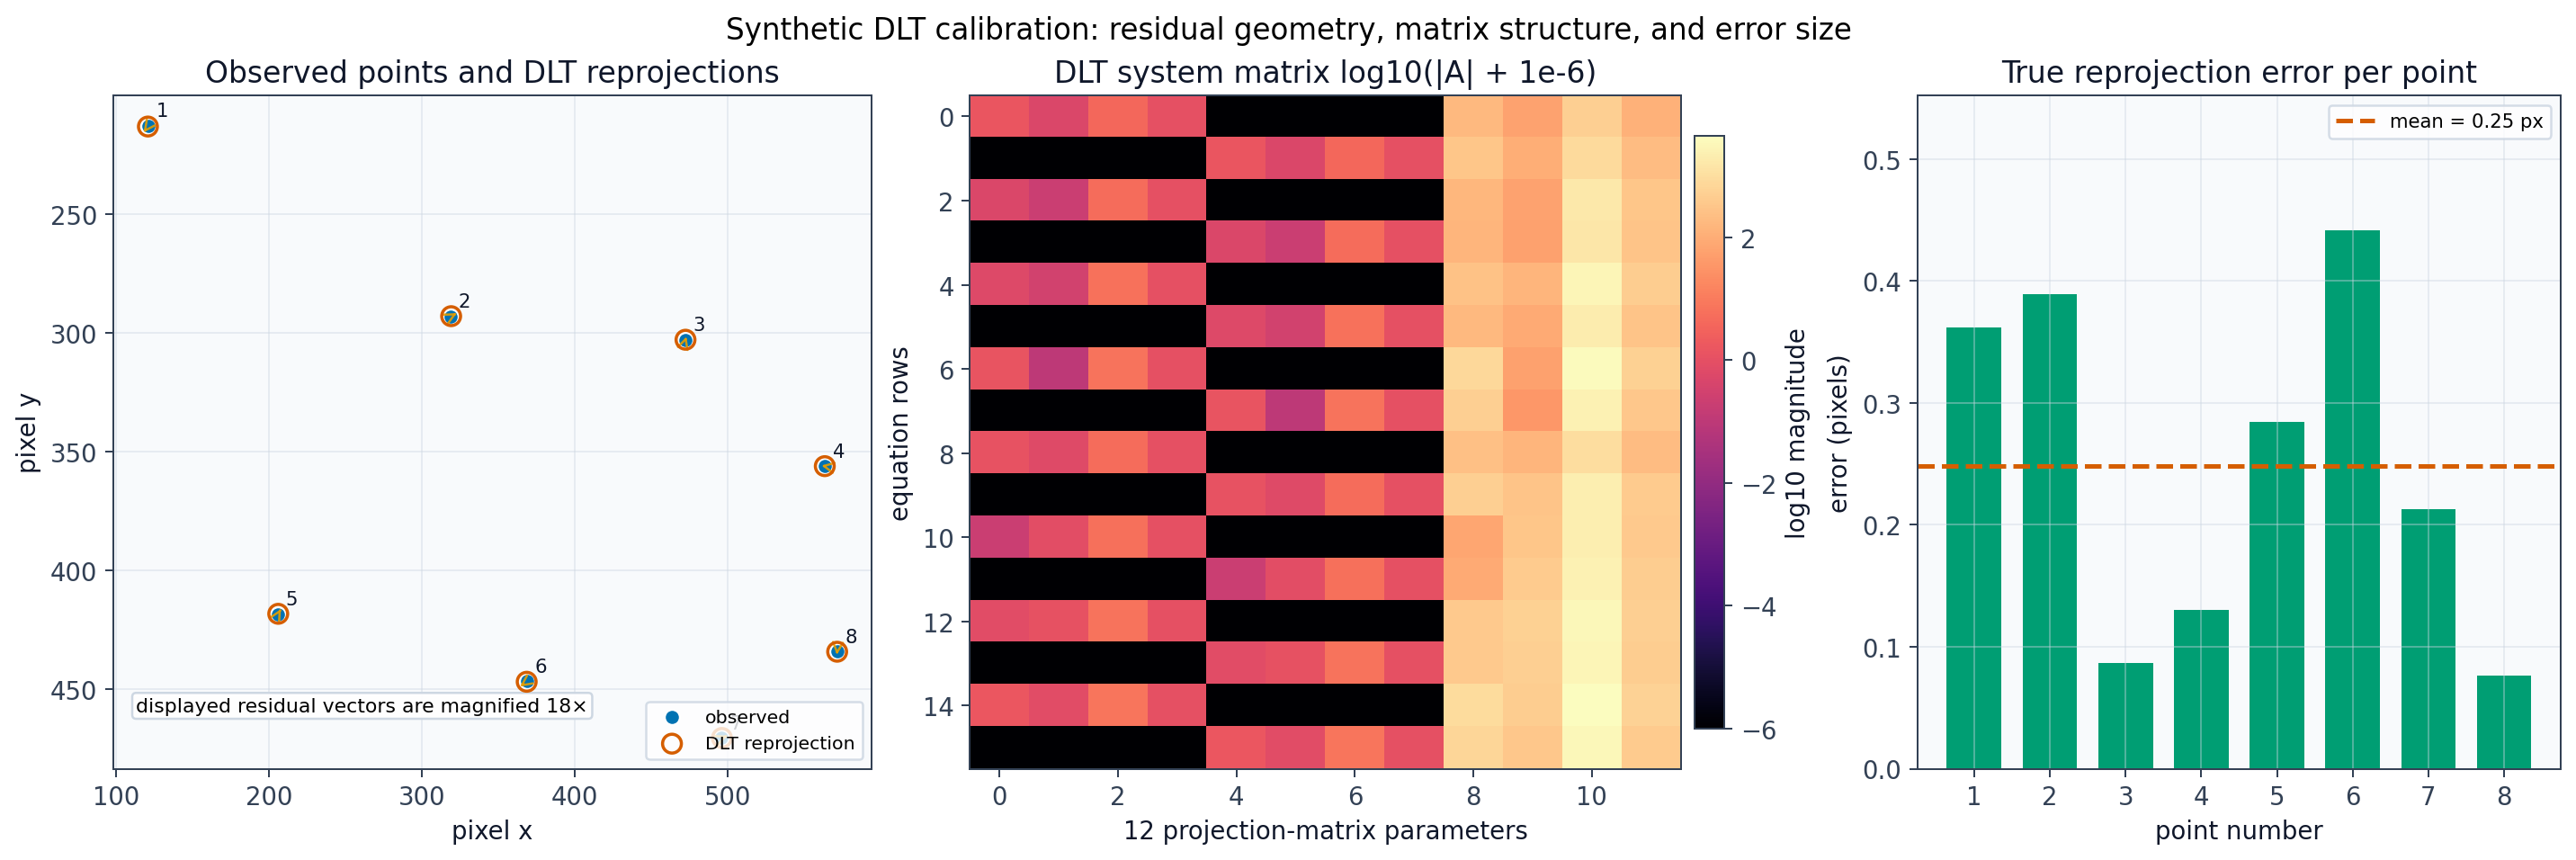

Estimated projection matrix (normalized):
tensor([[ 5.9194e-01, -7.8249e-02,  3.4478e-01, -7.8726e-02],
        [-4.3553e-02,  5.6133e-01,  3.2921e-01, -3.0505e-01],
        [-1.3287e-04, -1.7602e-04,  7.8526e-04,  3.0855e-04]],
       dtype=torch.float64)
Mean reprojection error: 0.248 px


In [6]:
world_points = torch.tensor(
    [
        [-1.5, -0.5,  4.0],
        [-0.5, -0.2,  5.2],
        [ 0.6, -0.3,  6.4],
        [ 1.4,  0.1,  7.0],
        [-1.2,  0.7,  5.0],
        [-0.2,  0.9,  6.0],
        [ 0.8,  1.1,  6.8],
        [ 1.6,  0.8,  8.0],
    ],
    dtype=torch.float64,
)

K_true = make_intrinsics(820.0, 790.0, 320.0, 240.0)
R_true = rotation_y(8.0) @ rotation_x(-12.0)
T_true = torch.tensor([0.3, 0.6, -0.4], dtype=torch.float64)

observed_pixels, _ = project_points(world_points, K_true, R_true, T_true)
noisy_pixels = observed_pixels + 0.8 * torch.tensor(
    [[0.5, -0.3], [-0.4, 0.2], [0.1, 0.4], [0.3, -0.5], [-0.2, 0.6], [0.4, -0.1], [-0.3, -0.2], [0.2, 0.3]],
    dtype=torch.float64,
)

M_est = estimate_projection_matrix_dlt(world_points, noisy_pixels)
reproj_clean = project_with_matrix(world_points, M_est)
reproj_error = torch.linalg.norm(reproj_clean - noisy_pixels, dim=1)
A = build_dlt_matrix(world_points, noisy_pixels)
A_display = torch.log10(A.abs() + 1e-6).numpy()
vector_scale = 18.0

fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.2), constrained_layout=True, gridspec_kw={"width_ratios": [1.12, 1.05, 0.95]})

ax = axes[0]
ax.scatter(noisy_pixels[:, 0], noisy_pixels[:, 1], color=COLORS["blue"], s=44, edgecolor="white", linewidth=0.8, label="observed", zorder=3)
ax.scatter(reproj_clean[:, 0], reproj_clean[:, 1], facecolor="none", edgecolor=COLORS["vermillion"], s=70, linewidth=1.4, label="DLT reprojection", zorder=4)
for idx, (obs, pred) in enumerate(zip(noisy_pixels, reproj_clean, strict=True), start=1):
    delta = pred - obs
    vis_end = obs + vector_scale * delta
    ax.annotate("", xy=(float(vis_end[0]), float(vis_end[1])), xytext=(float(obs[0]), float(obs[1])), arrowprops=dict(arrowstyle="->", lw=1.0, color=COLORS["orange"], alpha=0.9))
    ax.text(float(obs[0]) + 5.0, float(obs[1]) - 4.0, str(idx), fontsize=8.5, color="#0f172a")
ax.text(0.03, 0.08, f"displayed residual vectors are magnified {vector_scale:.0f}×", transform=ax.transAxes, ha="left", va="bottom", fontsize=8.8, bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="#cbd5e1", alpha=0.95))
ax.set_title("Observed points and DLT reprojections")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.invert_yaxis()
light_grid(ax)
ax.legend(loc="lower right", fontsize=8.2)

ax = axes[1]
im = ax.imshow(A_display, aspect="auto", cmap="magma")
ax.set_title("DLT system matrix log10(|A| + 1e-6)")
ax.set_xlabel("12 projection-matrix parameters")
ax.set_ylabel("equation rows")
cbar = fig.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
cbar.set_label("log10 magnitude", rotation=90)

ax = axes[2]
point_ids = torch.arange(1, len(reproj_error) + 1)
ax.bar(point_ids.numpy(), reproj_error.numpy(), color=COLORS["green"], width=0.72)
mean_error = float(reproj_error.mean())
ax.axhline(mean_error, color=COLORS["vermillion"], linestyle="--", lw=2.0, label=f"mean = {mean_error:.2f} px")
ax.set_title("True reprojection error per point")
ax.set_xlabel("point number")
ax.set_ylabel("error (pixels)")
ax.set_xticks(point_ids.numpy())
ax.set_ylim(0.0, max(float(reproj_error.max()) * 1.25, mean_error * 1.6))
light_grid(ax)
ax.legend(loc="upper right", fontsize=8.5)

fig.suptitle("Synthetic DLT calibration: residual geometry, matrix structure, and error size", fontsize=13)
savefig(fig, "05-dlt-reprojection-demo.png")

print("Estimated projection matrix (normalized):")
print(M_est)
print(f"Mean reprojection error: {reproj_error.mean().item():.3f} px")


**Computational reconstruction related to MIT Vision Book Section 39.7, Figure 39.14.**

We generated synthetic 3D points, projected them with a known camera, added small image noise, built the DLT linear system, and estimated a projection matrix up to scale. The left panel compares observed and predicted image points, the center panel shows the stacked DLT system, and the right panel summarizes reprojection error.


### Personal Toy Example: Measured Meeting-Room Calibration

This personal experiment mirrors the logic of MIT Figures 39.15–39.17 with a different scene: a meeting-room photograph taken by the notebook author, manual scene measurements in centimeters, manually identified `3D-2D` correspondences, normalized DLT camera estimation, reprojection validation, and 3D / top / side visualizations of the measured scene with the estimated camera.

The measured room is distinct from MIT's office example. The goal here is not to reproduce MIT's office data, but to follow the same calibration workflow on a personally measured scene with transparent assumptions and explicitly documented exclusions.


Measurement table used for the meeting-room model (centimeters):


measurement,value_cm,source segment,status
Wall height,300.00,Yellow vertical blue-wall segment,direct
Television width,148.00,Green segment along the TV lower edge,direct
Television lower-edge height,110.00,Magenta vertical segment from floor line to TV lower-left corner,direct
Television upper-edge height,258.00,Derived as 110 + 148 from the TV lower edge and TV height assumption,derived
Blue-wall span from TV reference to opening left jamb,193.00,Long green wall segment under the TV,direct
Glass opening width,213.00,Brown segment across the lower opening,direct
Opening right-jamb x coordinate,406.00,Derived as 193 + 213 along the same wall direction,derived
Table setback from wall reference,70.00,Cyan floor segment from the wall-floor reference to the back-left table support line,direct
Table width,120.00,Red segment across the back and front table edges,direct
Table length,240.00,Cyan segments along both visible long table edges,direct


Excluded or ambiguous measurements:
- The red 98 cm annotation near the left chairs was excluded because its endpoints do not align with a single stable geometric scene feature.
- The cyan 48 cm annotation near the wall-floor junction was excluded because its upper anchor is not a uniquely identifiable physical corner in the photograph.
- The plant measurements 61 cm, 53 cm, and 28 cm were excluded from calibration because the box footprint corners are partially occluded and not sharp enough for repeatable 2D corner selection.
Selected 3D-2D correspondences:


id,description,world (cm),image (px),object,status
P1,Wall-floor reference directly below the TV-left measurement,"(0.0, 0.0, 0.0)","(231.0, 722.0)",blue wall / floor,direct
P2,Wall-ceiling point above the wall reference,"(0.0, 300.0, 0.0)","(203.0, 206.0)",blue wall,derived
P3,TV lower-left corner,"(0.0, 110.0, 0.0)","(212.0, 558.0)",television on blue wall,direct
P4,TV lower-right corner,"(148.0, 110.0, 0.0)","(470.0, 552.0)",television on blue wall,direct
P5,TV upper-left corner,"(0.0, 258.0, 0.0)","(209.0, 394.0)",television on blue wall,derived
P6,TV upper-right corner,"(148.0, 258.0, 0.0)","(470.0, 408.0)",television on blue wall,derived
P7,Opening lower-left corner,"(193.0, 0.0, 0.0)","(500.0, 549.0)",opening on blue wall,direct
P8,Opening upper-left corner,"(193.0, 300.0, 0.0)","(505.0, 210.0)",opening on blue wall,derived
P9,Opening lower-right corner,"(406.0, 0.0, 0.0)","(872.0, 552.0)",opening on blue wall,derived
P10,Opening upper-right corner,"(406.0, 300.0, 0.0)","(900.0, 106.0)",opening on blue wall,derived


Correspondence diagnostics:
- Number of correspondences: 14
- Distinct supporting planes: 3 (blue wall (Z = 0), floor (Y = 0), table top (Y = 75))
- Rank of centered 3D coordinates: 3
- Rank of the normalized DLT design matrix: 12
- Coordinate ranges (cm): X in [0.0, 406.0], Y in [0.0, 300.0], Z in [0.0, 310.0]
- Full camera-matrix estimation suitable: True
Estimated 3x4 projection matrix (normalized DLT):
[[ -719.6158   117.6105    89.9055 -106135.5590]
 [  148.1754   672.8072   465.3478 -312217.3559]
 [   -0.0557     0.2142     0.9752  -440.0282]]
Recovered camera factors:
[[  706.8375  -129.4199   152.9490]
 [    0.0000   586.0743   589.6532]
 [    0.0000     0.0000     1.0000]]
[[    0.9495    -0.2908     0.1181]
 [   -0.3089    -0.9325     0.1872]
 [    0.0557    -0.2142    -0.9752]]
translation vector t = [  -71.4209   -90.0113  -440.0282]
camera center C = [    -64.52     198.95     403.84] cm
rotation determinant = 1.000000
rotation orthogonality error = 1.642042e-16
positive c

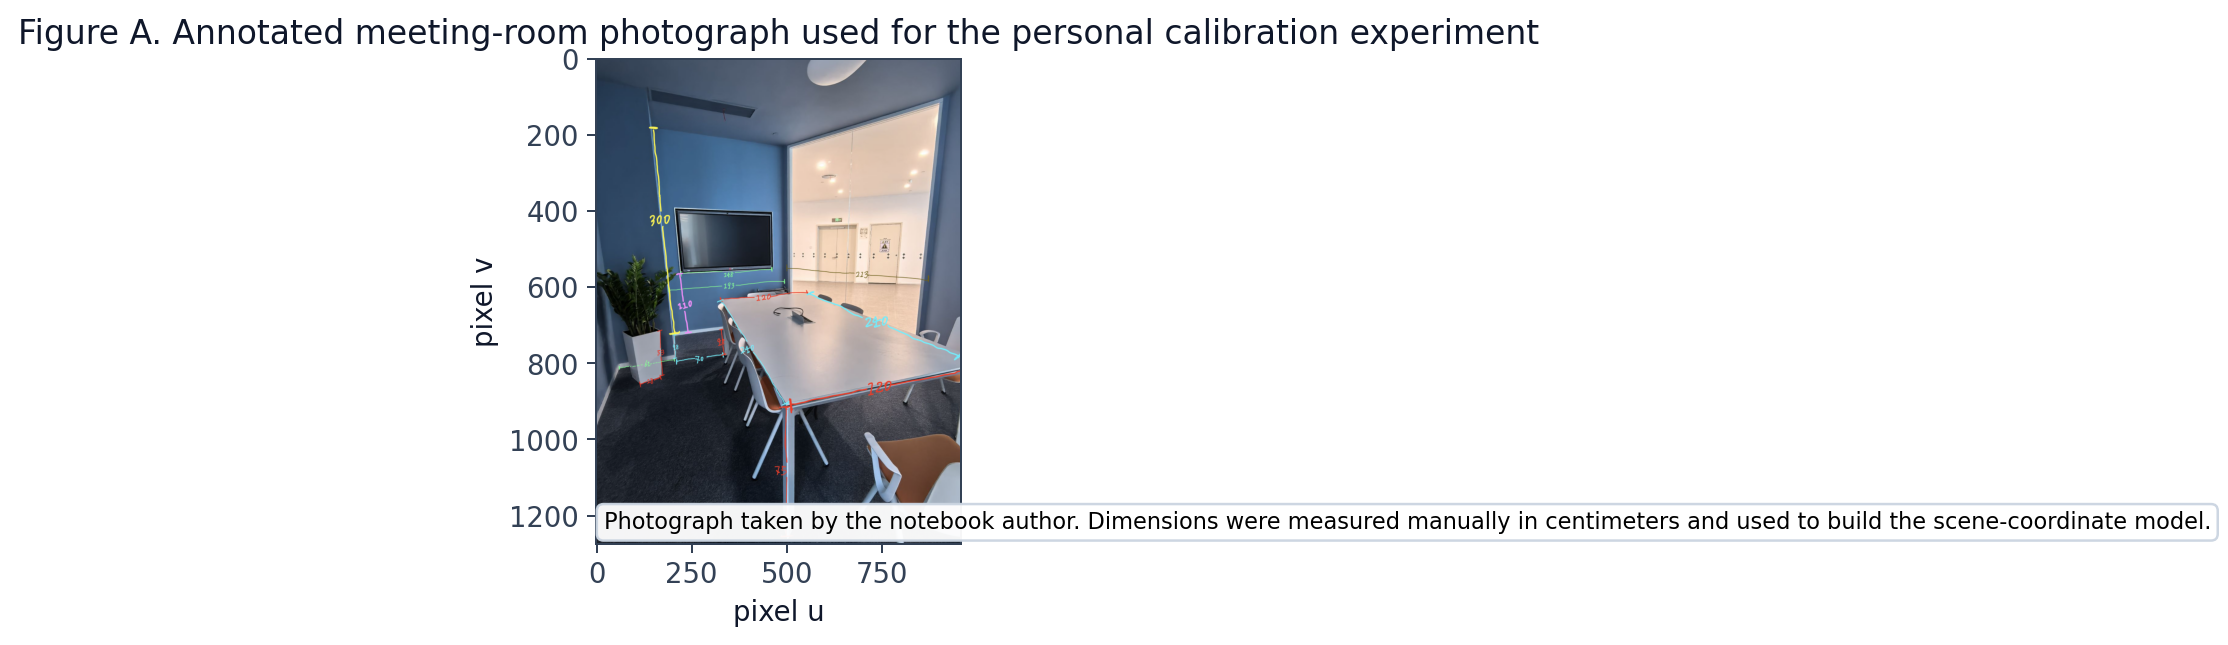

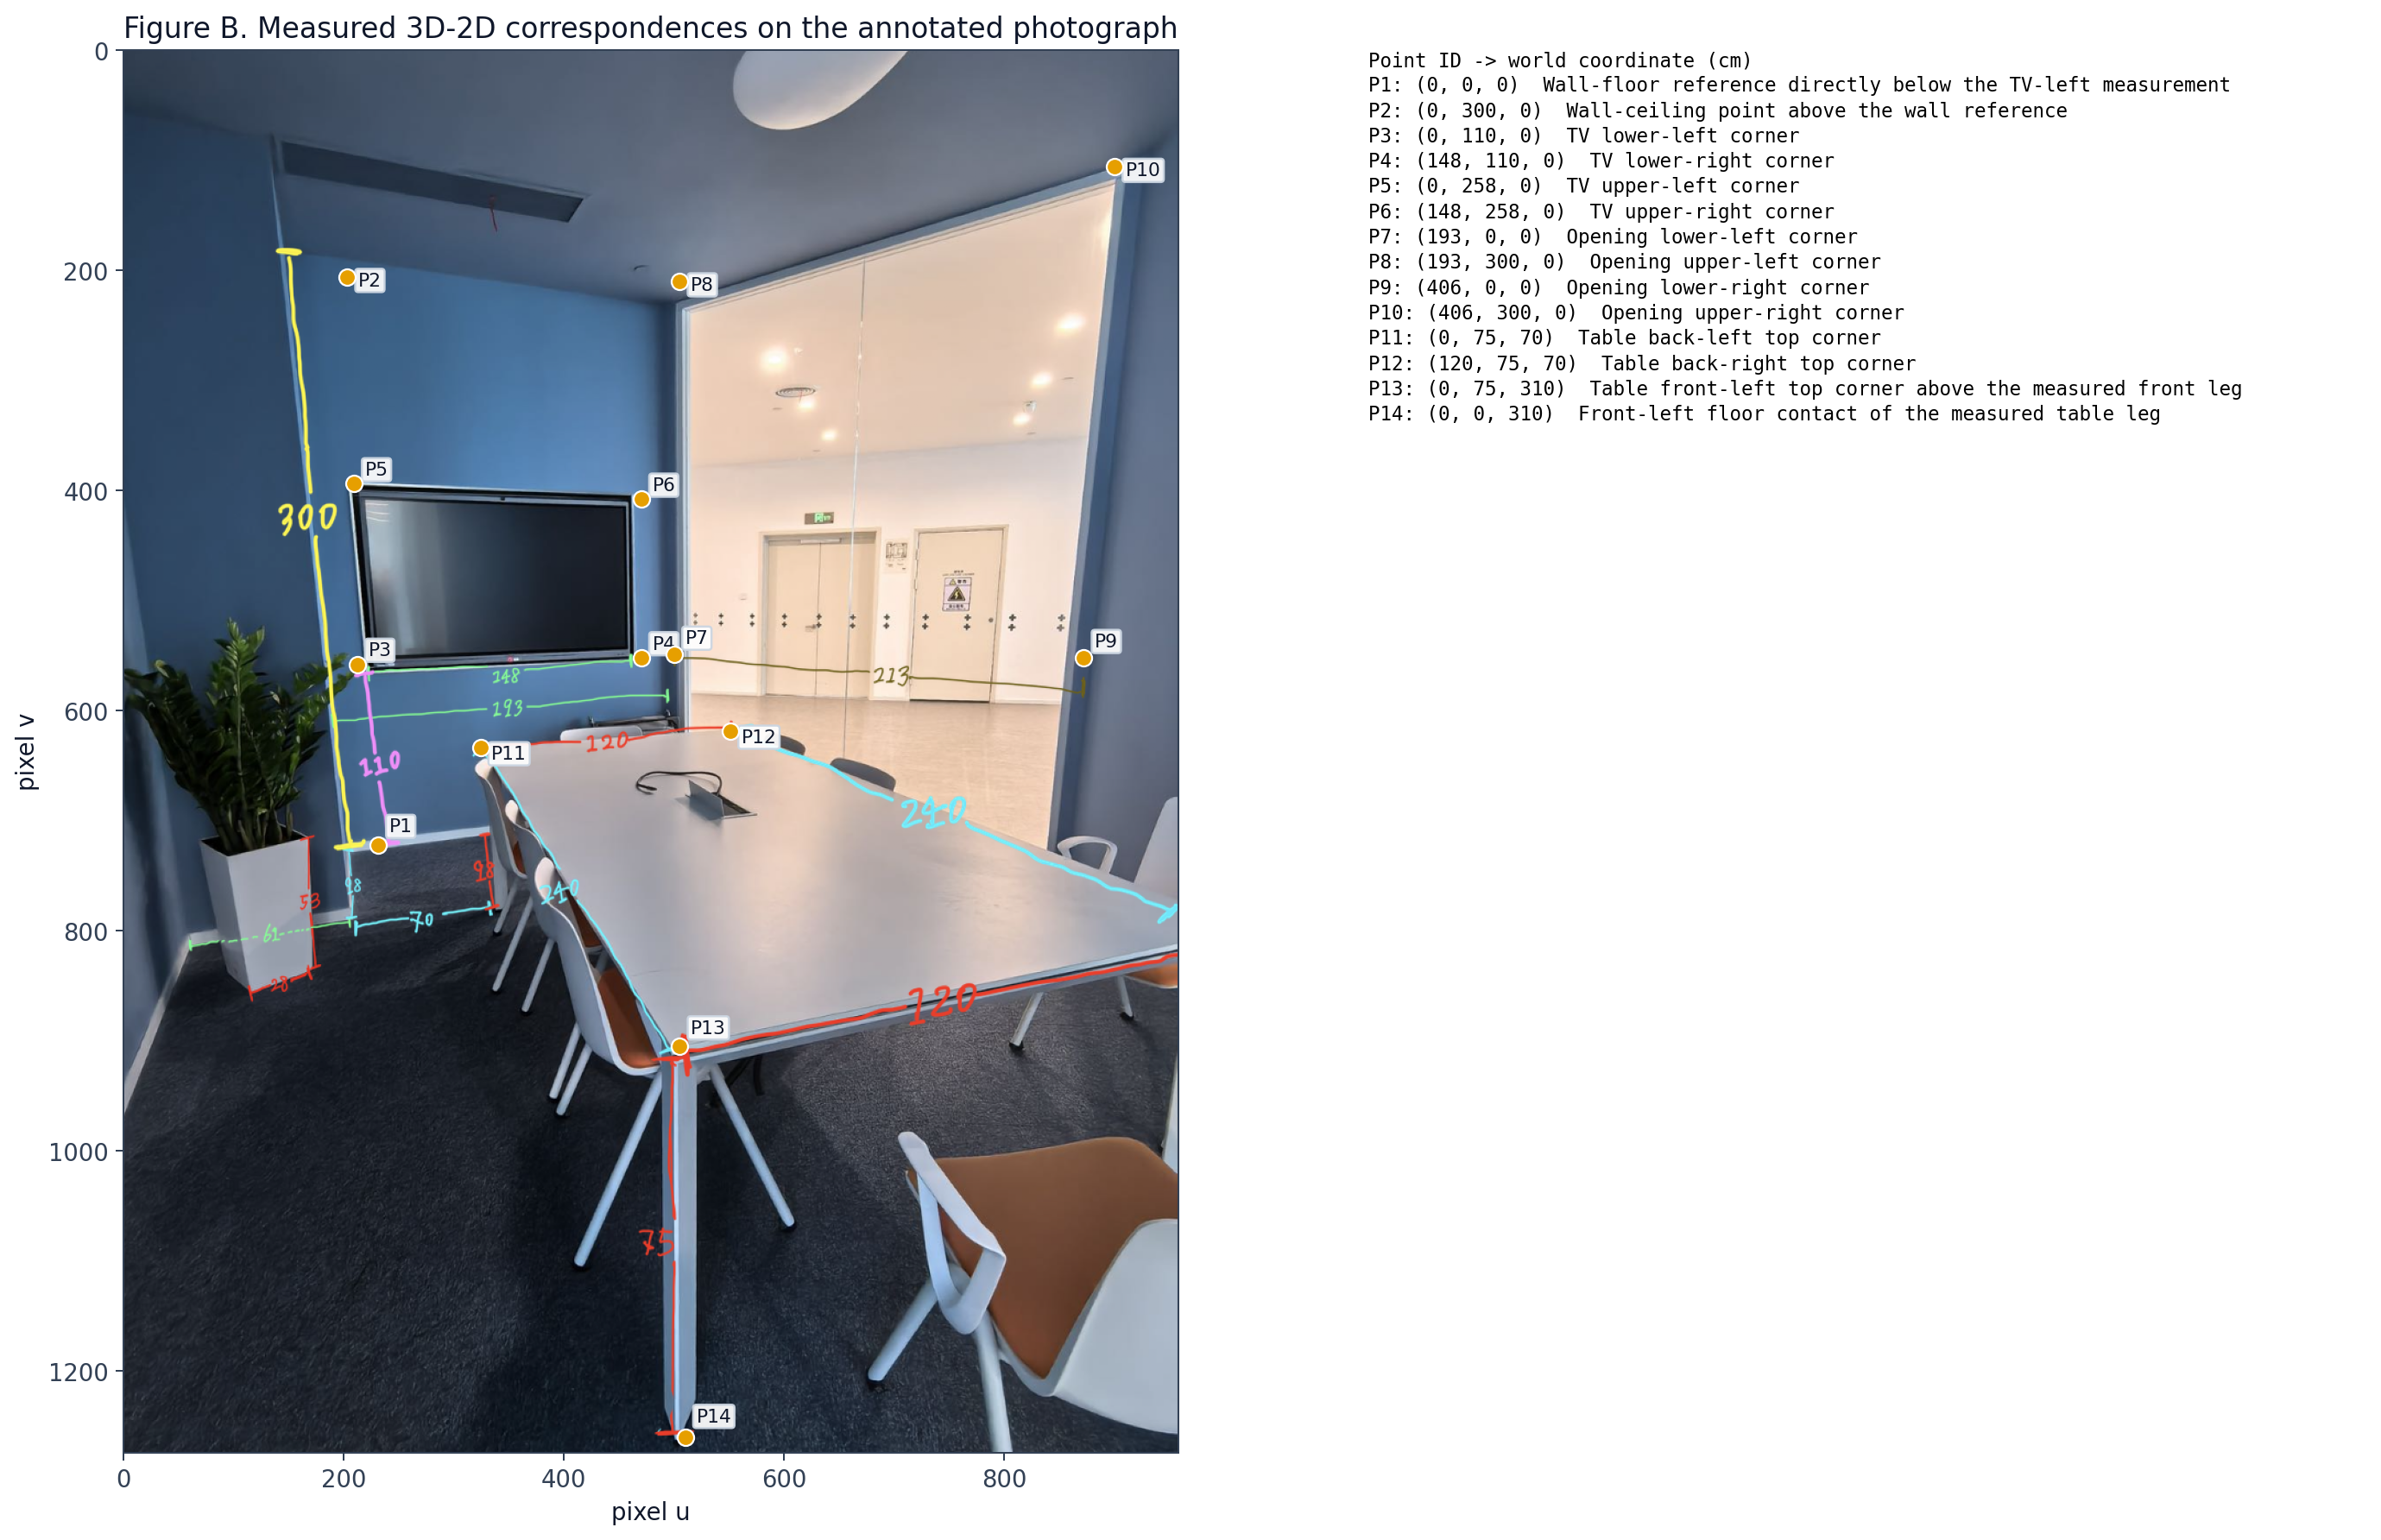

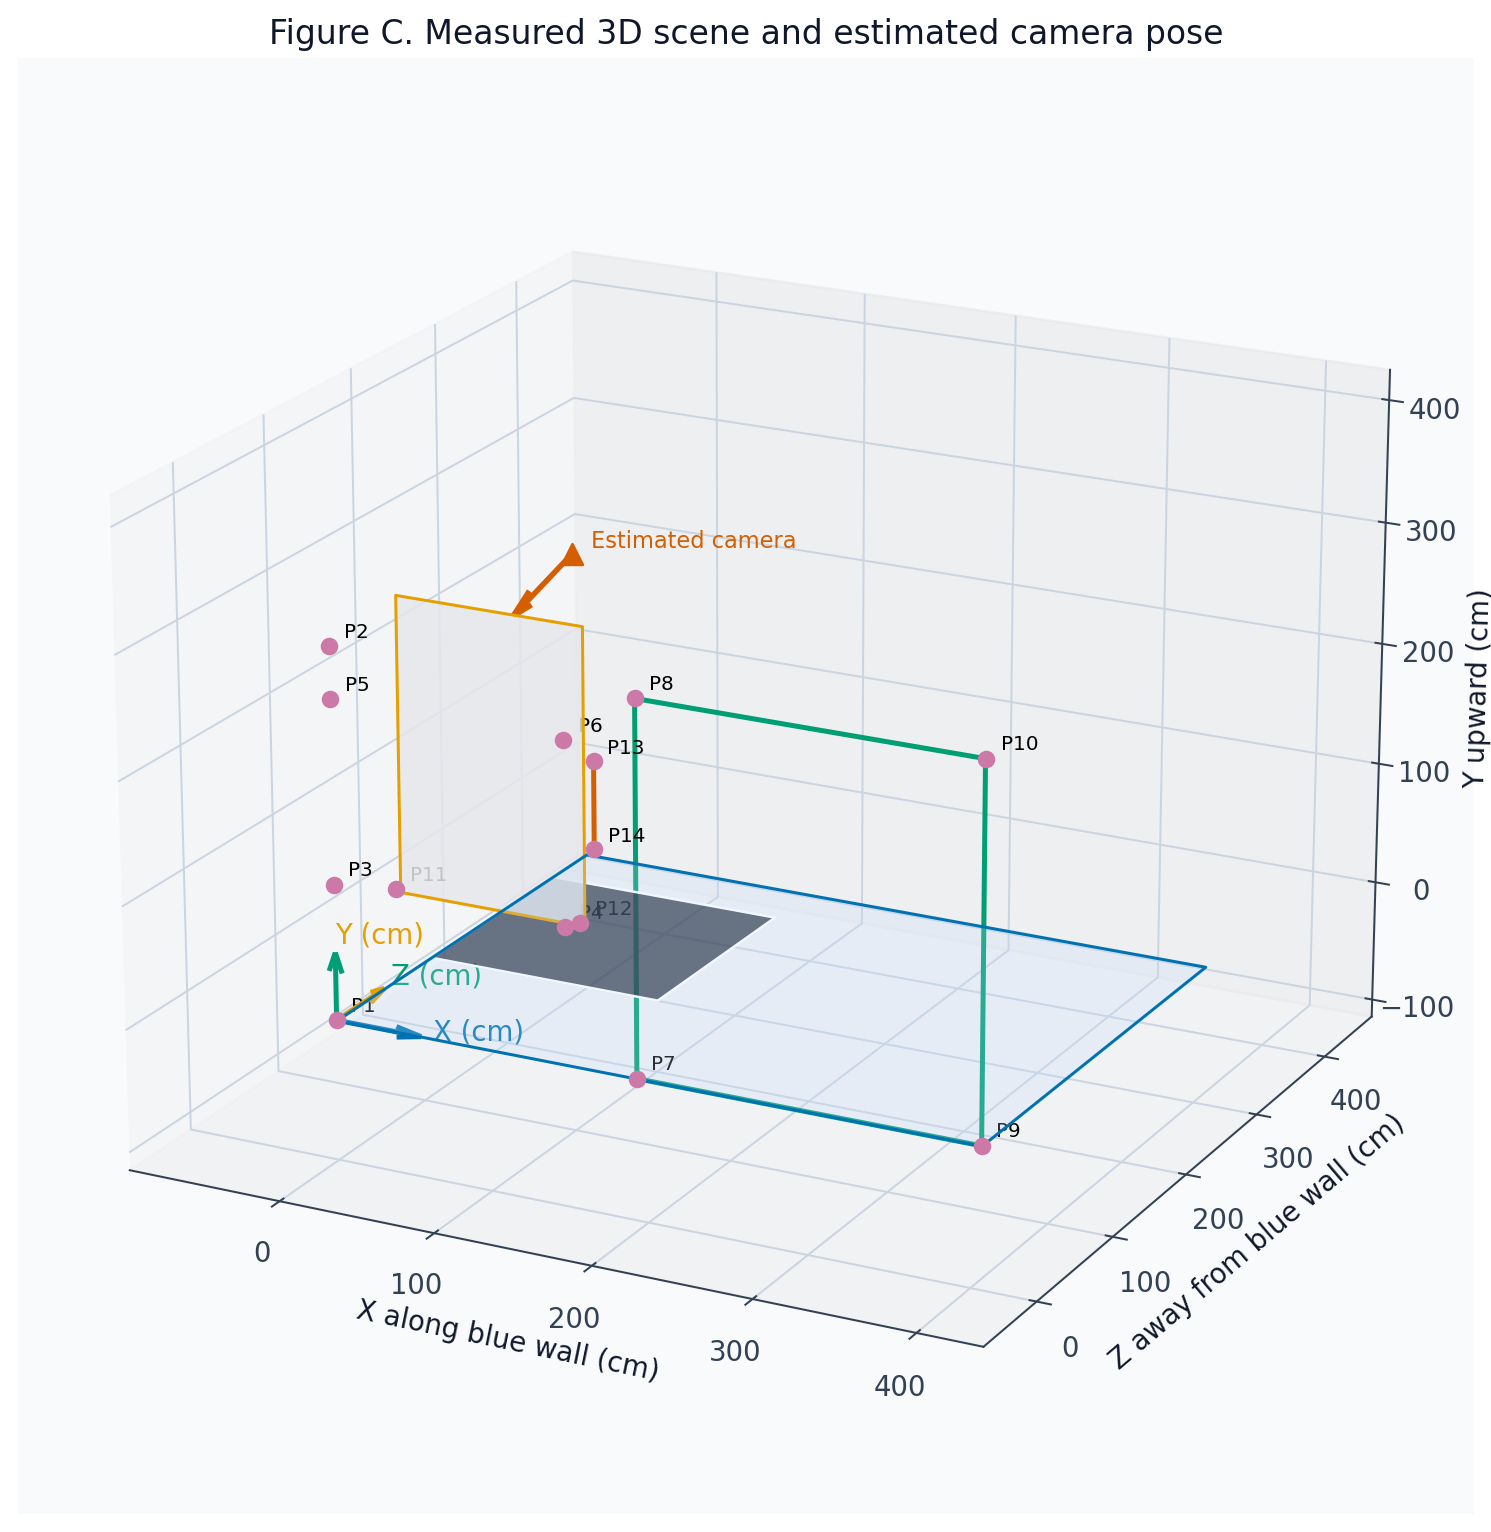

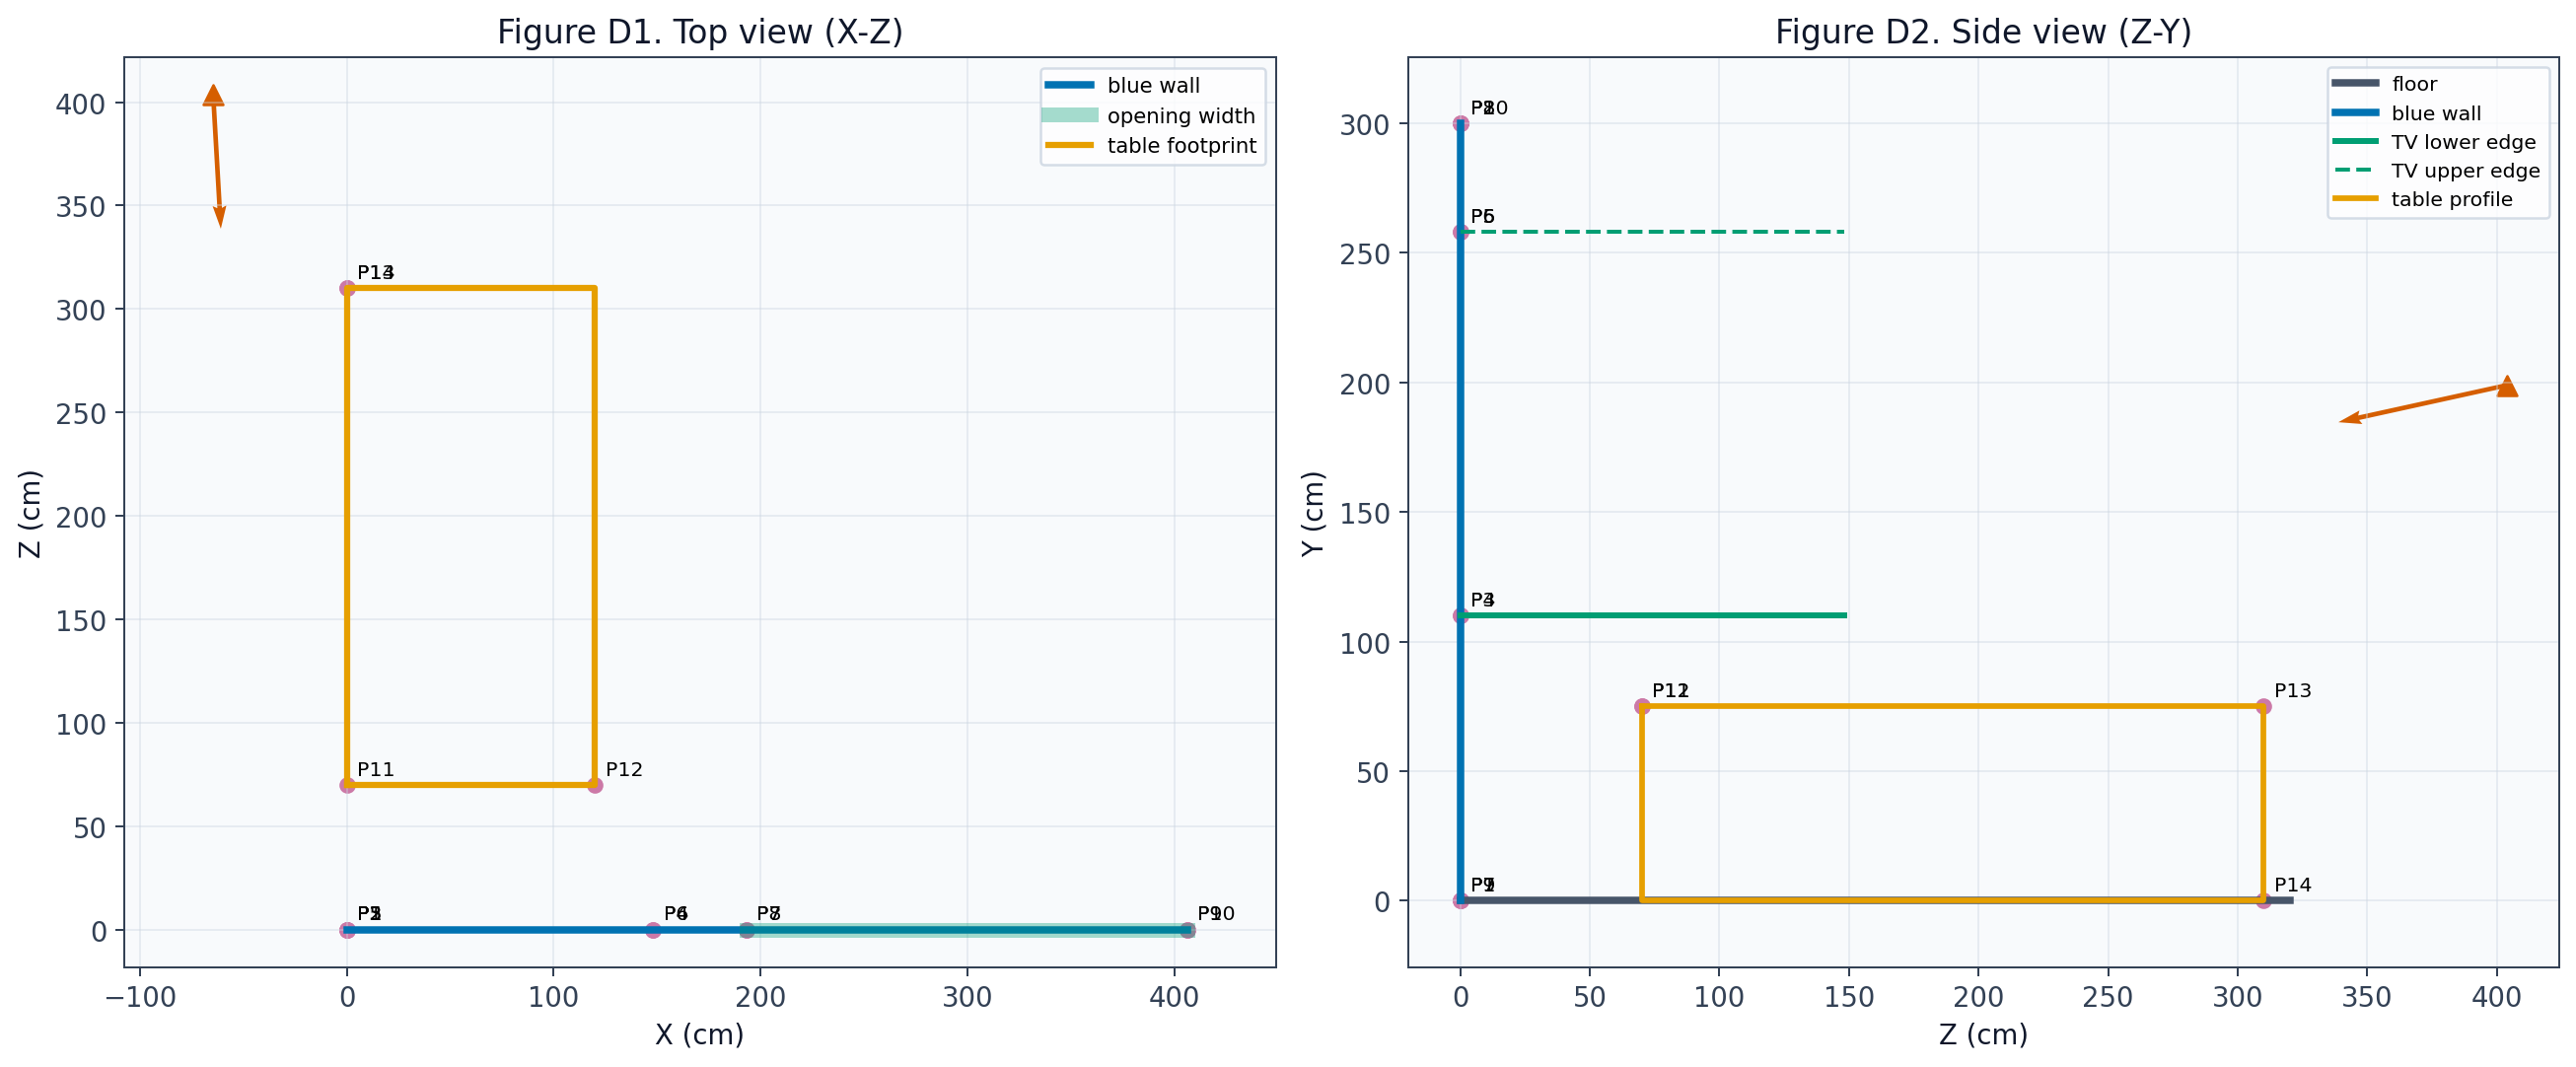

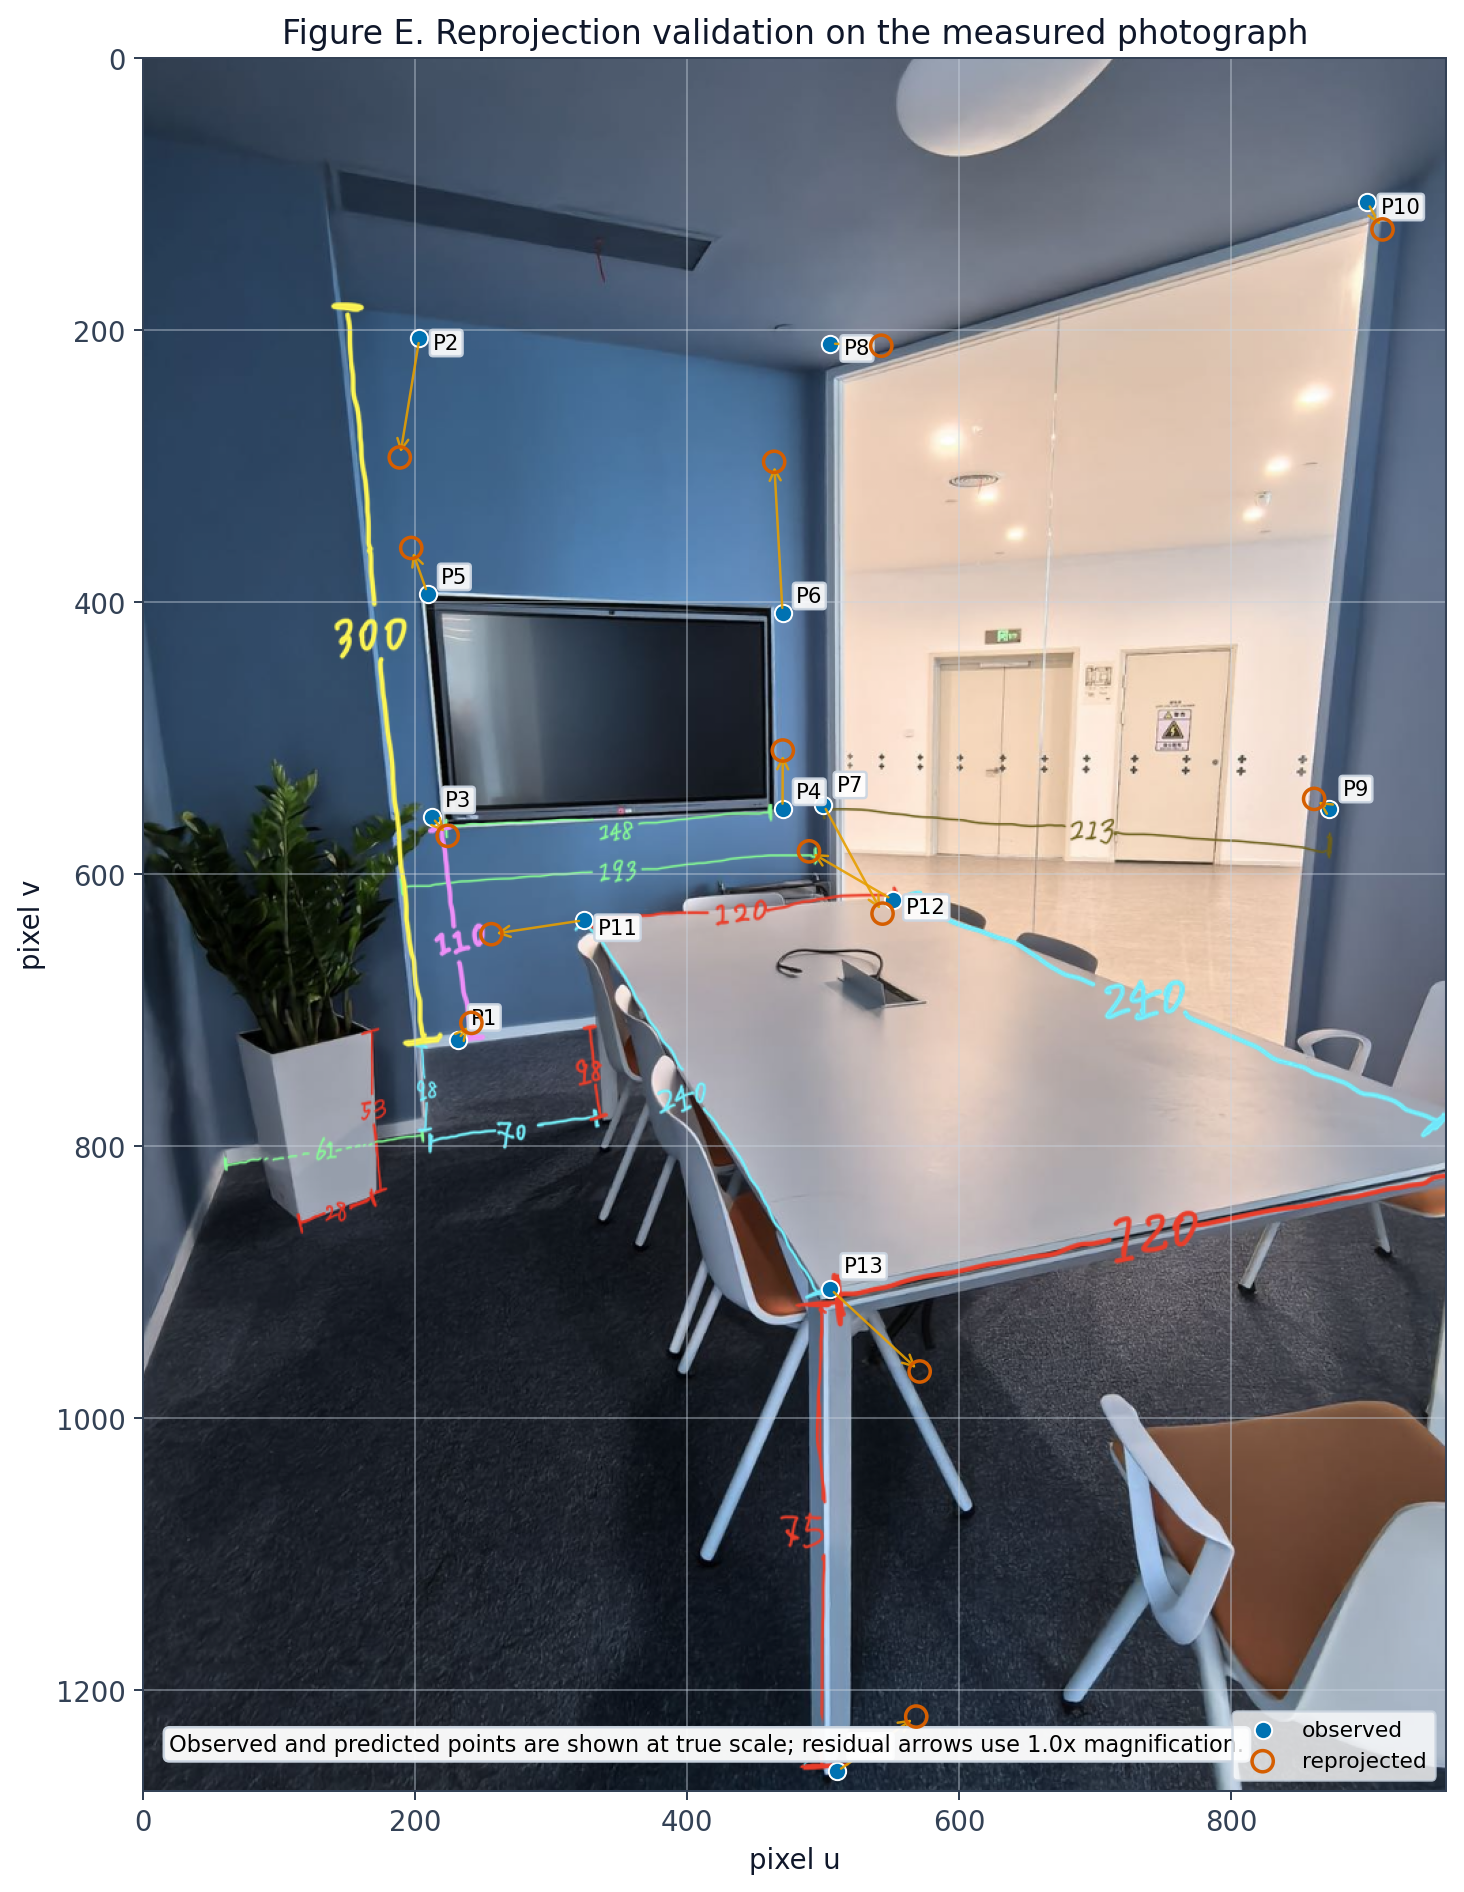

Per-point reprojection summary:


id,"observed (u, v)","predicted (u, v)",fit error (px),leave-one-out error (px)
P1,"(231.0, 722.0)","(241.2, 709.5)",16.10,38.22
P2,"(203.0, 206.0)","(188.5, 293.7)",88.91,141.31
P3,"(212.0, 558.0)","(223.8, 572.0)",18.28,24.22
P4,"(470.0, 552.0)","(470.2, 509.2)",42.77,49.02
P5,"(209.0, 394.0)","(197.0, 360.3)",35.78,48.19
P6,"(470.0, 408.0)","(463.8, 296.9)",111.23,131.72
P7,"(500.0, 549.0)","(543.6, 629.2)",91.24,119.99
P8,"(505.0, 210.0)","(542.6, 211.6)",37.66,54.59
P9,"(872.0, 552.0)","(860.9, 544.8)",13.20,86.69
P10,"(900.0, 106.0)","(911.2, 126.0)",22.97,69.12


Reprojection error statistics: mean = 55.62 px, median = 55.82 px, RMS = 63.97 px, max = 111.23 px.
Largest-error point: P6 with 111.23 px. A plausible cause is the combination of manual pixel selection, rounded table geometry, and simplified single-view scene offsets.
Leave-one-out reprojection sensitivity: mean = 111.57 px, median = 82.73 px, max = 345.44 px.
All correspondences were used for fitting; leave-one-out sensitivity is reported instead of a fixed holdout split.
Interpretation:
- The measured wall, opening, and table points are sufficient to estimate a full projective camera from one photograph.
- The recovered camera can be plotted back into the measured room coordinate system, which makes the single-view pose estimate interpretable.
- Reprojection error checks whether the estimated camera remains self-consistent with the annotated image, even though the measurements are approximate.
- Remaining error is expected because the scene dimensions, pixel picks, and lens model ar

In [7]:
annotated_image_path = CHAPTER_DIR / "biaoding.jpg"
assert annotated_image_path.exists(), f"Missing annotated meeting-room image: {annotated_image_path}"

image = plt.imread(annotated_image_path)
image_height, image_width = image.shape[:2]

measurement_rows = [
    {"measurement": "Wall height", "value_cm": 300.0, "source segment": "Yellow vertical blue-wall segment", "status": "direct"},
    {"measurement": "Television width", "value_cm": 148.0, "source segment": "Green segment along the TV lower edge", "status": "direct"},
    {"measurement": "Television lower-edge height", "value_cm": 110.0, "source segment": "Magenta vertical segment from floor line to TV lower-left corner", "status": "direct"},
    {"measurement": "Television upper-edge height", "value_cm": 258.0, "source segment": "Derived as 110 + 148 from the TV lower edge and TV height assumption", "status": "derived"},
    {"measurement": "Blue-wall span from TV reference to opening left jamb", "value_cm": 193.0, "source segment": "Long green wall segment under the TV", "status": "direct"},
    {"measurement": "Glass opening width", "value_cm": 213.0, "source segment": "Brown segment across the lower opening", "status": "direct"},
    {"measurement": "Opening right-jamb x coordinate", "value_cm": 406.0, "source segment": "Derived as 193 + 213 along the same wall direction", "status": "derived"},
    {"measurement": "Table setback from wall reference", "value_cm": 70.0, "source segment": "Cyan floor segment from the wall-floor reference to the back-left table support line", "status": "direct"},
    {"measurement": "Table width", "value_cm": 120.0, "source segment": "Red segment across the back and front table edges", "status": "direct"},
    {"measurement": "Table length", "value_cm": 240.0, "source segment": "Cyan segments along both visible long table edges", "status": "direct"},
    {"measurement": "Table height", "value_cm": 75.0, "source segment": "Red segment along the front table leg", "status": "direct"},
    {"measurement": "Table front-edge depth", "value_cm": 310.0, "source segment": "Derived as 70 + 240 from the wall reference to the near table edge", "status": "derived"},
]

excluded_measurements = [
    "The red 98 cm annotation near the left chairs was excluded because its endpoints do not align with a single stable geometric scene feature.",
    "The cyan 48 cm annotation near the wall-floor junction was excluded because its upper anchor is not a uniquely identifiable physical corner in the photograph.",
    "The plant measurements 61 cm, 53 cm, and 28 cm were excluded from calibration because the box footprint corners are partially occluded and not sharp enough for repeatable 2D corner selection.",
]

print("Measurement table used for the meeting-room model (centimeters):")
render_html_table(measurement_rows, ["measurement", "value_cm", "source segment", "status"])
print("Excluded or ambiguous measurements:")
for item in excluded_measurements:
    print(f"- {item}")

point_rows = [
    {"id": "P1", "description": "Wall-floor reference directly below the TV-left measurement", "world": (0.0, 0.0, 0.0), "pixel": (231.0, 722.0), "object": "blue wall / floor", "status": "direct"},
    {"id": "P2", "description": "Wall-ceiling point above the wall reference", "world": (0.0, 300.0, 0.0), "pixel": (203.0, 206.0), "object": "blue wall", "status": "derived"},
    {"id": "P3", "description": "TV lower-left corner", "world": (0.0, 110.0, 0.0), "pixel": (212.0, 558.0), "object": "television on blue wall", "status": "direct"},
    {"id": "P4", "description": "TV lower-right corner", "world": (148.0, 110.0, 0.0), "pixel": (470.0, 552.0), "object": "television on blue wall", "status": "direct"},
    {"id": "P5", "description": "TV upper-left corner", "world": (0.0, 258.0, 0.0), "pixel": (209.0, 394.0), "object": "television on blue wall", "status": "derived"},
    {"id": "P6", "description": "TV upper-right corner", "world": (148.0, 258.0, 0.0), "pixel": (470.0, 408.0), "object": "television on blue wall", "status": "derived"},
    {"id": "P7", "description": "Opening lower-left corner", "world": (193.0, 0.0, 0.0), "pixel": (500.0, 549.0), "object": "opening on blue wall", "status": "direct"},
    {"id": "P8", "description": "Opening upper-left corner", "world": (193.0, 300.0, 0.0), "pixel": (505.0, 210.0), "object": "opening on blue wall", "status": "derived"},
    {"id": "P9", "description": "Opening lower-right corner", "world": (406.0, 0.0, 0.0), "pixel": (872.0, 552.0), "object": "opening on blue wall", "status": "derived"},
    {"id": "P10", "description": "Opening upper-right corner", "world": (406.0, 300.0, 0.0), "pixel": (900.0, 106.0), "object": "opening on blue wall", "status": "derived"},
    {"id": "P11", "description": "Table back-left top corner", "world": (0.0, 75.0, 70.0), "pixel": (324.0, 634.0), "object": "table top", "status": "derived"},
    {"id": "P12", "description": "Table back-right top corner", "world": (120.0, 75.0, 70.0), "pixel": (551.0, 619.0), "object": "table top", "status": "derived"},
    {"id": "P13", "description": "Table front-left top corner above the measured front leg", "world": (0.0, 75.0, 310.0), "pixel": (505.0, 905.0), "object": "table top", "status": "derived"},
    {"id": "P14", "description": "Front-left floor contact of the measured table leg", "world": (0.0, 0.0, 310.0), "pixel": (510.0, 1260.0), "object": "floor / table leg", "status": "direct"},
]

print("Selected 3D-2D correspondences:")
correspondence_display_rows = []
for row in point_rows:
    correspondence_display_rows.append(
        {
            "id": row["id"],
            "description": row["description"],
            "world (cm)": row["world"],
            "image (px)": row["pixel"],
            "object": row["object"],
            "status": row["status"],
        }
    )
render_html_table(correspondence_display_rows, ["id", "description", "world (cm)", "image (px)", "object", "status"])

world_points_real = np.array([row["world"] for row in point_rows], dtype=np.float64)
image_points_real = np.array([row["pixel"] for row in point_rows], dtype=np.float64)

supporting_planes = set()
if np.any(np.isclose(world_points_real[:, 2], 0.0)):
    supporting_planes.add("blue wall (Z = 0)")
if np.any(np.isclose(world_points_real[:, 1], 0.0)):
    supporting_planes.add("floor (Y = 0)")
if np.any(np.isclose(world_points_real[:, 1], 75.0)):
    supporting_planes.add("table top (Y = 75)")

_, singular_values, _ = np.linalg.svd(world_points_real - world_points_real.mean(axis=0), full_matrices=False)
noncoplanar_rank = int(np.sum(singular_values > 1e-6))
trial_projection, dlt_matrix = estimate_projection_matrix_normalized_dlt(world_points_real, image_points_real)
dlt_rank = int(np.linalg.matrix_rank(dlt_matrix))
configuration_valid = len(point_rows) >= 6 and noncoplanar_rank >= 3 and dlt_rank >= 11

print("Correspondence diagnostics:")
print(f"- Number of correspondences: {len(point_rows)}")
print(f"- Distinct supporting planes: {len(supporting_planes)} ({', '.join(sorted(supporting_planes))})")
print(f"- Rank of centered 3D coordinates: {noncoplanar_rank}")
print(f"- Rank of the normalized DLT design matrix: {dlt_rank}")
print(
    "- Coordinate ranges (cm): "
    f"X in [{world_points_real[:, 0].min():.1f}, {world_points_real[:, 0].max():.1f}], "
    f"Y in [{world_points_real[:, 1].min():.1f}, {world_points_real[:, 1].max():.1f}], "
    f"Z in [{world_points_real[:, 2].min():.1f}, {world_points_real[:, 2].max():.1f}]"
)
print(f"- Full camera-matrix estimation suitable: {configuration_valid}")
assert configuration_valid, "The measured correspondence configuration was not sufficient for full camera estimation."

projection_real, dlt_matrix = estimate_projection_matrix_normalized_dlt(world_points_real, image_points_real)
reprojected_points = project_with_projection_matrix(world_points_real, projection_real)
reprojection_error = np.linalg.norm(reprojected_points - image_points_real, axis=1)
mean_error = float(reprojection_error.mean())
median_error = float(np.median(reprojection_error))
rms_error = float(np.sqrt(np.mean(reprojection_error ** 2)))
max_error = float(reprojection_error.max())
worst_index = int(np.argmax(reprojection_error))
worst_point_id = point_rows[worst_index]["id"]

intrinsics_real, rotation_real, translation_real, camera_center_real = decompose_projection_matrix(projection_real)
sign_matrix_report = np.diag(
    [
        -1.0 if intrinsics_real[0, 0] < 0.0 else 1.0,
        -1.0 if intrinsics_real[1, 1] < 0.0 else 1.0,
        1.0,
    ]
)
intrinsics_real = intrinsics_real @ sign_matrix_report
rotation_real = sign_matrix_report @ rotation_real
translation_real = np.linalg.solve(intrinsics_real, projection_real[:, 3])
rotation_det = float(np.linalg.det(rotation_real))
orthogonality_error = float(np.linalg.norm(rotation_real @ rotation_real.T - np.eye(3), ord="fro"))
view_direction_world = rotation_real.T @ np.array([0.0, 0.0, 1.0], dtype=np.float64)
view_direction_world = view_direction_world / np.linalg.norm(view_direction_world)
camera_space_points = (rotation_real @ (world_points_real.T - camera_center_real[:, None])).T
positive_depth_ratio = float(np.mean(camera_space_points[:, 2] > 0.0))

leave_one_out_errors = []
for holdout_index in range(len(point_rows)):
    train_mask = np.ones(len(point_rows), dtype=bool)
    train_mask[holdout_index] = False
    projection_loo, _ = estimate_projection_matrix_normalized_dlt(world_points_real[train_mask], image_points_real[train_mask])
    predicted_holdout = project_with_projection_matrix(world_points_real[[holdout_index]], projection_loo)[0]
    holdout_error = float(np.linalg.norm(predicted_holdout - image_points_real[holdout_index]))
    leave_one_out_errors.append(holdout_error)

print("Estimated 3x4 projection matrix (normalized DLT):")
print(np.array2string(projection_real, formatter={"float_kind": lambda value: f"{value:10.4f}"}))
print("Recovered camera factors:")
print(np.array2string(intrinsics_real, formatter={"float_kind": lambda value: f"{value:10.4f}"}))
print(np.array2string(rotation_real, formatter={"float_kind": lambda value: f"{value:10.4f}"}))
print(f"translation vector t = {np.array2string(translation_real, formatter={'float_kind': lambda value: f'{value:10.4f}'})}")
print(f"camera center C = {np.array2string(camera_center_real, formatter={'float_kind': lambda value: f'{value:10.2f}'})} cm")
print(f"rotation determinant = {rotation_det:.6f}")
print(f"rotation orthogonality error = {orthogonality_error:.6e}")
print(
    f"positive camera-space depths = {(camera_space_points[:, 2] > 0.0).sum()} / {len(point_rows)} "
    f"({100.0 * positive_depth_ratio:.1f}%)"
)
print(
    f"estimated focal lengths: fx = {intrinsics_real[0, 0]:.2f}, fy = {intrinsics_real[1, 1]:.2f}; "
    f"principal point = ({intrinsics_real[0, 2]:.2f}, {intrinsics_real[1, 2]:.2f})"
)

fig, ax = plt.subplots(figsize=(7.8, 10.4), constrained_layout=True)
ax.imshow(image)
ax.set_title("Figure A. Annotated meeting-room photograph used for the personal calibration experiment")
ax.set_xlabel("pixel u")
ax.set_ylabel("pixel v")
ax.text(
    0.02,
    0.02,
    "Photograph taken by the notebook author. Dimensions were measured manually in centimeters and used to build the scene-coordinate model.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9.0,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cbd5e1", alpha=0.96),
)
savefig(fig, "personal-figure-a-inline")

label_offsets = {
    "P1": (10, -12), "P2": (10, 8), "P3": (10, -8), "P4": (10, -8), "P5": (10, -8), "P6": (10, -8),
    "P7": (10, -10), "P8": (10, 8), "P9": (10, -10), "P10": (10, 8), "P11": (10, 10), "P12": (10, 10),
    "P13": (10, -12), "P14": (10, -14),
}

fig, (ax_img, ax_tbl) = plt.subplots(
    1,
    2,
    figsize=(15.6, 9.8),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [1.25, 0.9]},
)
ax_img.imshow(image)
ax_img.set_title("Figure B. Measured 3D-2D correspondences on the annotated photograph")
ax_img.set_xlabel("pixel u")
ax_img.set_ylabel("pixel v")
for row in point_rows:
    u_coord, v_coord = row["pixel"]
    dx, dy = label_offsets[row["id"]]
    ax_img.scatter([u_coord], [v_coord], s=58, color=COLORS["orange"], edgecolors="white", linewidths=0.9, zorder=4)
    ax_img.text(
        u_coord + dx,
        v_coord + dy,
        row["id"],
        fontsize=8.7,
        color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="#cbd5e1", alpha=0.93),
    )
ax_img.set_xlim(0, image_width)
ax_img.set_ylim(image_height, 0)

ax_tbl.axis("off")
legend_lines = ["Point ID -> world coordinate (cm)"]
for row in point_rows:
    X, Y, Z = row["world"]
    legend_lines.append(f"{row['id']}: ({X:.0f}, {Y:.0f}, {Z:.0f})  {row['description']}")
ax_tbl.text(
    0.0,
    1.0,
    "\n".join(legend_lines),
    ha="left",
    va="top",
    fontsize=9.0,
    family="monospace",
    linespacing=1.35,
)
savefig(fig, "personal-figure-b-inline")

wall_polygon = np.array([[0.0, 0.0, 0.0], [406.0, 0.0, 0.0], [406.0, 300.0, 0.0], [0.0, 300.0, 0.0]])
tv_polygon = np.array([[0.0, 110.0, 0.0], [148.0, 110.0, 0.0], [148.0, 258.0, 0.0], [0.0, 258.0, 0.0]])
table_polygon = np.array([[0.0, 75.0, 70.0], [120.0, 75.0, 70.0], [120.0, 75.0, 310.0], [0.0, 75.0, 310.0]])
opening_frame = np.array([[193.0, 0.0, 0.0], [406.0, 0.0, 0.0], [406.0, 300.0, 0.0], [193.0, 300.0, 0.0], [193.0, 0.0, 0.0]])
leg_segment = np.array([[0.0, 0.0, 310.0], [0.0, 75.0, 310.0]])

fig = plt.figure(figsize=(12.8, 8.4), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(Poly3DCollection([wall_polygon], facecolors="#bfdbfe", edgecolors=COLORS["blue"], linewidths=1.2, alpha=0.22))
ax.add_collection3d(Poly3DCollection([tv_polygon], facecolors="#111827", edgecolors="white", linewidths=1.0, alpha=0.72))
ax.add_collection3d(Poly3DCollection([table_polygon], facecolors="#e5e7eb", edgecolors=COLORS["orange"], linewidths=1.2, alpha=0.85))
ax.plot(opening_frame[:, 0], opening_frame[:, 2], opening_frame[:, 1], color=COLORS["green"], linewidth=2.0)
ax.plot(leg_segment[:, 0], leg_segment[:, 2], leg_segment[:, 1], color=COLORS["vermillion"], linewidth=2.0)
ax.scatter(world_points_real[:, 0], world_points_real[:, 2], world_points_real[:, 1], color=COLORS["purple"], s=36, depthshade=False)
for row in point_rows:
    X, Y, Z = row["world"]
    ax.text(X + 6.0, Z + 6.0, Y + 6.0, row["id"], fontsize=8.0)
ax.scatter([camera_center_real[0]], [camera_center_real[2]], [camera_center_real[1]], color=COLORS["vermillion"], s=70, marker="^", depthshade=False)
ax.quiver(
    camera_center_real[0],
    camera_center_real[2],
    camera_center_real[1],
    view_direction_world[0],
    view_direction_world[2],
    view_direction_world[1],
    length=85.0,
    color=COLORS["vermillion"],
    linewidth=2.2,
)
axis_origin = np.array([0.0, 0.0, 0.0])
axis_scale = 55.0
ax.quiver(axis_origin[0], axis_origin[2], axis_origin[1], axis_scale, 0.0, 0.0, color=COLORS["blue"], linewidth=2.0)
ax.quiver(axis_origin[0], axis_origin[2], axis_origin[1], 0.0, 0.0, axis_scale, color=COLORS["green"], linewidth=2.0)
ax.quiver(axis_origin[0], axis_origin[2], axis_origin[1], 0.0, axis_scale, 0.0, color=COLORS["orange"], linewidth=2.0)
ax.text(axis_scale + 8.0, 0.0, 0.0, "X (cm)", color=COLORS["blue"])
ax.text(0.0, axis_scale + 8.0, 0.0, "Z (cm)", color=COLORS["green"])
ax.text(0.0, 0.0, axis_scale + 8.0, "Y (cm)", color=COLORS["orange"])
ax.text(camera_center_real[0] + 10.0, camera_center_real[2] + 6.0, camera_center_real[1] + 6.0, "Estimated camera", color=COLORS["vermillion"], fontsize=9.0)
ax.set_title("Figure C. Measured 3D scene and estimated camera pose")
ax.set_xlabel("X along blue wall (cm)")
ax.set_ylabel("Z away from blue wall (cm)")
ax.set_zlabel("Y upward (cm)")
ax.view_init(elev=20, azim=-63)
set_axes_equal(ax)
savefig(fig, "personal-figure-c-inline")

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.9), constrained_layout=True)

top_ax = axes[0]
top_ax.plot([0.0, 406.0], [0.0, 0.0], color=COLORS["blue"], linewidth=3.0, label="blue wall")
top_ax.plot([193.0, 406.0], [0.0, 0.0], color=COLORS["green"], linewidth=6.0, alpha=0.35, label="opening width")
table_xz = np.array([[0.0, 70.0], [120.0, 70.0], [120.0, 310.0], [0.0, 310.0], [0.0, 70.0]])
top_ax.plot(table_xz[:, 0], table_xz[:, 1], color=COLORS["orange"], linewidth=2.5, label="table footprint")
top_ax.scatter(world_points_real[:, 0], world_points_real[:, 2], color=COLORS["purple"], s=32)
for row in point_rows:
    X, _, Z = row["world"]
    top_ax.text(X + 5.0, Z + 5.0, row["id"], fontsize=8.2)
top_ax.scatter([camera_center_real[0]], [camera_center_real[2]], color=COLORS["vermillion"], s=64, marker="^")
top_ax.quiver(camera_center_real[0], camera_center_real[2], view_direction_world[0], view_direction_world[2], angles="xy", scale_units="xy", scale=0.015, color=COLORS["vermillion"], width=0.004)
top_ax.set_title("Figure D1. Top view (X-Z)")
top_ax.set_xlabel("X (cm)")
top_ax.set_ylabel("Z (cm)")
light_grid(top_ax)
top_ax.axis("equal")
top_ax.legend(loc="upper right", fontsize=8.5)

side_ax = axes[1]
side_ax.plot([0.0, 320.0], [0.0, 0.0], color=COLORS["gray"], linewidth=3.0, label="floor")
side_ax.plot([0.0, 0.0], [0.0, 300.0], color=COLORS["blue"], linewidth=3.0, label="blue wall")
side_ax.plot([0.0, 148.0], [110.0, 110.0], color=COLORS["green"], linewidth=2.4, label="TV lower edge")
side_ax.plot([0.0, 148.0], [258.0, 258.0], color=COLORS["green"], linewidth=1.6, linestyle="--", label="TV upper edge")
side_ax.plot([70.0, 310.0, 310.0, 70.0, 70.0], [75.0, 75.0, 0.0, 0.0, 75.0], color=COLORS["orange"], linewidth=2.3, label="table profile")
side_ax.scatter(world_points_real[:, 2], world_points_real[:, 1], color=COLORS["purple"], s=32)
for row in point_rows:
    _, Y, Z = row["world"]
    side_ax.text(Z + 4.0, Y + 4.0, row["id"], fontsize=8.2)
side_ax.scatter([camera_center_real[2]], [camera_center_real[1]], color=COLORS["vermillion"], s=64, marker="^")
side_ax.quiver(camera_center_real[2], camera_center_real[1], view_direction_world[2], view_direction_world[1], angles="xy", scale_units="xy", scale=0.015, color=COLORS["vermillion"], width=0.004)
side_ax.set_title("Figure D2. Side view (Z-Y)")
side_ax.set_xlabel("Z (cm)")
side_ax.set_ylabel("Y (cm)")
light_grid(side_ax)
side_ax.axis("equal")
side_ax.legend(loc="upper right", fontsize=8.2)
savefig(fig, "personal-figure-d-inline")

residual_scale = 1.0
fig, ax = plt.subplots(figsize=(8.0, 10.4), constrained_layout=True)
ax.imshow(image)
ax.scatter(image_points_real[:, 0], image_points_real[:, 1], color=COLORS["blue"], s=48, edgecolors="white", linewidths=0.8, label="observed", zorder=3)
ax.scatter(reprojected_points[:, 0], reprojected_points[:, 1], facecolors="none", edgecolors=COLORS["vermillion"], s=72, linewidths=1.4, label="reprojected", zorder=4)
for row, observed, predicted in zip(point_rows, image_points_real, reprojected_points, strict=True):
    delta = predicted - observed
    displayed_end = observed + residual_scale * delta
    ax.annotate(
        "",
        xy=(displayed_end[0], displayed_end[1]),
        xytext=(observed[0], observed[1]),
        arrowprops=dict(arrowstyle="->", lw=1.0, color=COLORS["orange"], alpha=0.9),
    )
    dx, dy = label_offsets[row["id"]]
    ax.text(
        observed[0] + dx,
        observed[1] + dy,
        row["id"],
        fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="#cbd5e1", alpha=0.93),
    )
ax.set_title("Figure E. Reprojection validation on the measured photograph")
ax.set_xlabel("pixel u")
ax.set_ylabel("pixel v")
ax.set_xlim(0, image_width)
ax.set_ylim(image_height, 0)
ax.text(
    0.02,
    0.02,
    f"Observed and predicted points are shown at true scale; residual arrows use {residual_scale:.1f}x magnification.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9.0,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cbd5e1", alpha=0.96),
)
light_grid(ax)
ax.legend(loc="lower right", fontsize=8.7)
savefig(fig, "personal-figure-e-inline")

error_rows = []
for row, observed, predicted, error_value, loo_error in zip(point_rows, image_points_real, reprojected_points, reprojection_error, leave_one_out_errors, strict=True):
    error_rows.append(
        {
            "id": row["id"],
            "observed (u, v)": f"({observed[0]:.1f}, {observed[1]:.1f})",
            "predicted (u, v)": f"({predicted[0]:.1f}, {predicted[1]:.1f})",
            "fit error (px)": float(error_value),
            "leave-one-out error (px)": float(loo_error),
        }
    )

print("Per-point reprojection summary:")
render_html_table(error_rows, ["id", "observed (u, v)", "predicted (u, v)", "fit error (px)", "leave-one-out error (px)"])
print(
    f"Reprojection error statistics: mean = {mean_error:.2f} px, median = {median_error:.2f} px, "
    f"RMS = {rms_error:.2f} px, max = {max_error:.2f} px."
)
print(
    f"Largest-error point: {worst_point_id} with {max_error:.2f} px. "
    "A plausible cause is the combination of manual pixel selection, rounded table geometry, and simplified single-view scene offsets."
)
print(
    f"Leave-one-out reprojection sensitivity: mean = {np.mean(leave_one_out_errors):.2f} px, "
    f"median = {np.median(leave_one_out_errors):.2f} px, max = {np.max(leave_one_out_errors):.2f} px."
)
print("All correspondences were used for fitting; leave-one-out sensitivity is reported instead of a fixed holdout split.")

print("Interpretation:")
print("- The measured wall, opening, and table points are sufficient to estimate a full projective camera from one photograph.")
print("- The recovered camera can be plotted back into the measured room coordinate system, which makes the single-view pose estimate interpretable.")
print("- Reprojection error checks whether the estimated camera remains self-consistent with the annotated image, even though the measurements are approximate.")
print("- Remaining error is expected because the scene dimensions, pixel picks, and lens model are all simplified compared with a controlled calibration rig.")


## 39.8 Concluding Remarks

The chapter's practical message is simple: a camera model is only useful when it links
geometry, coordinates, and measurable image data. Intrinsics explain how rays become
pixels, extrinsics explain where the camera is, and calibration ties both pieces to real
correspondences.


## Section Coverage

| Section | Topic | Original figures included | Generated visualization | Coverage status |
| --- | --- | --- | --- | --- |
| 39.1 | Introduction | 39.1, 39.2 | None | Covered |
| 39.2 | Homogeneous perspective projection | 39.3 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.2.1 | Parallel projection | None | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3 | Camera-intrinsic parameters | 39.4, 39.5, 39.6, 39.7 | Inline PyTorch/Matplotlib visualizations | Covered |
| 39.3.1 | From meters to pixels | 39.4, 39.5 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3.2 | From pixels to rays | 39.6 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.3.3 | Simple calibration method | 39.7 | None | Covered |
| 39.3.4 | Other camera parameters | None | None | Concise coverage |
| 39.4 | Camera-extrinsic parameters | 39.8 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.5 | Full camera model | 39.9 | None | Covered |
| 39.6 | Concrete examples | 39.10, 39.11, 39.12, 39.13 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7 | Camera calibration | 39.14, 39.15, 39.16, 39.17 | Inline PyTorch/Matplotlib visualization | Covered |
| 39.7.1 | Direct linear transform | None | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7.2 | Recover intrinsics and extrinsics | None | Explanation only | Concise coverage |
| 39.7.3 | Multiplane calibration | None | Explanation only | Concise coverage |
| 39.7.4 | Reprojection error minimization | 39.14 | Inline PyTorch/Matplotlib visualization | Covered with visualization |
| 39.7.5 | Toy example | 39.15, 39.16, 39.17 | Explanation only | Covered |
| 39.8 | Concluding remarks | None | None | Concise coverage |


## Figure Coverage

| Figure | Section | Original included | Generated counterpart | Treatment |
| --- | --- | --- | --- | --- |
| 39.1 | 39.1 | Yes | None | Original figure with explanation |
| 39.2 | 39.1 | Yes | None | Original figure with explanation |
| 39.3 | 39.2 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.4 | 39.3.1 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.5 | 39.3.1 | Yes | None | Original figure with explanation |
| 39.6 | 39.3.2 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.7 | 39.3.3 | Yes, two panels | None | Original figure with explanation |
| 39.8 | 39.4 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.9 | 39.5 | Yes | None | Original figure with explanation |
| 39.10 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.11 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.12 | 39.6 | Yes | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.13 | 39.6 | Yes, two panels | Inline PyTorch/Matplotlib visualization | Supplemental visualization |
| 39.14 | 39.7.4 | Yes | Inline PyTorch/Matplotlib visualization | Computational reconstruction |
| 39.15 | 39.7.5 | Yes | None | Original figure with explanation |
| 39.16 | 39.7.5 | Yes | None | Original figure with explanation |
| 39.17 | 39.7.5 | Yes | None | Original figure with explanation |


In [8]:
print("Inline generated figures executed successfully in this notebook run.")


Inline generated figures executed successfully in this notebook run.
